# 🌳 Decision Trees from Scratch
### A Complete Learning Journey — Entropy to Pruning, Concept to Code

---

**What you'll learn in this notebook:**
1. What is a Decision Tree and how does it make decisions?
2. Impurity measures — Entropy, Gini Index, and Variance
3. Information Gain — the splitting criterion
4. Building a Classification Tree from scratch (CART algorithm)
5. Visualizing the tree structure and decision boundaries
6. Regression Trees — predicting continuous values
7. Overfitting and Pruning — controlling tree complexity
8. Feature importance from Decision Trees
9. Full evaluation suite

> **Philosophy:** Every formula is derived. Every line of code is explained. We use **only NumPy** — no sklearn for the model itself.

In [1]:
# ─────────────────────────────────────────────
#  IMPORTS — only numpy and matplotlib
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#e0e0e0',
    'text.color':       '#e0e0e0',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'grid.color':       '#333',
    'grid.alpha':       0.5,
    'figure.dpi':       120,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

COLORS = ['#00d4ff', '#ff6b6b', '#ffd166', '#06d6a0', '#a855f7', '#f97316']
print("✅ Imports done. Let's grow some Decision Trees from scratch!")

✅ Imports done. Let's grow some Decision Trees from scratch!


---
## Part 1 — What Is a Decision Tree?

A **Decision Tree** is a flowchart-like structure where:
- Each **internal node** asks a yes/no question about a feature: `Is x₁ ≤ 3.5?`
- Each **branch** represents the answer (yes / no)
- Each **leaf node** gives the final prediction

**Key idea:** At every node, we find the feature and threshold that **best splits** the data — separating different classes as cleanly as possible.

**Why Decision Trees?**
- ✅ Highly interpretable — you can explain every decision
- ✅ No feature scaling needed
- ✅ Handles both classification and regression
- ✅ Captures non-linear relationships
- ⚠️ Prone to overfitting (deep trees memorize noise)
- ⚠️ Unstable — small data changes → very different tree

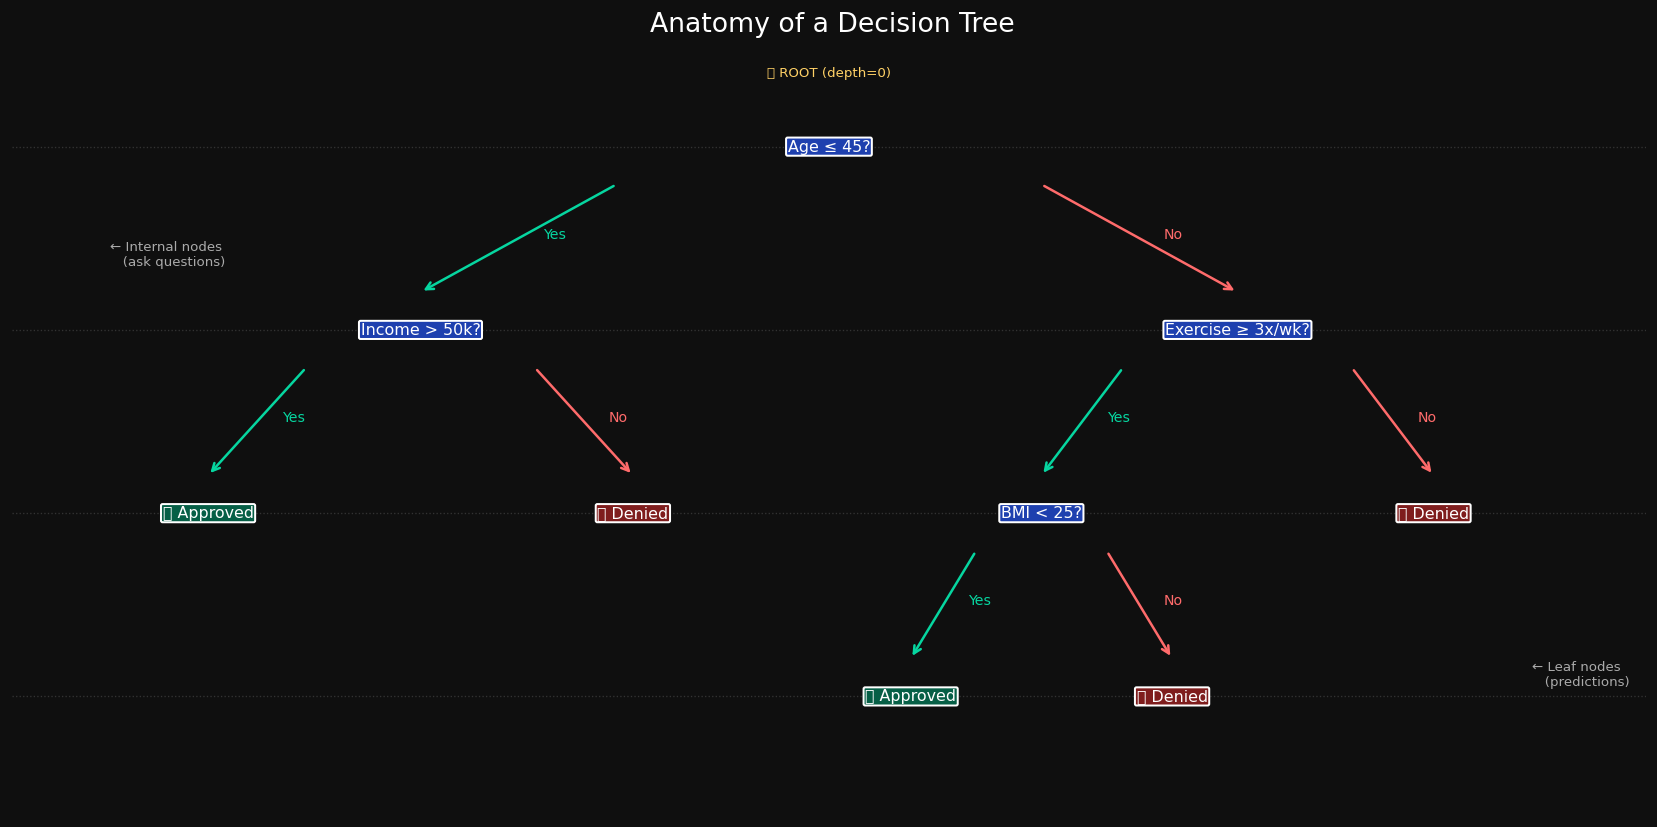

🌳 A decision tree is just a series of if/else rules stacked into a hierarchy.
   The art is in figuring out WHICH feature and threshold to split on at each node.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
#  Visualize the concept of a Decision Tree as a flowchart
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis('off')
fig.suptitle('Anatomy of a Decision Tree', fontsize=16, color='white')

# Node drawing helper
def draw_node(ax, x, y, text, color, width=2.4, height=0.7, style='round,pad=0.1'):
    ax.text(x, y, text, ha='center', va='center', fontsize=9.5, color='white',
            bbox=dict(boxstyle=style, facecolor=color, edgecolor='white', linewidth=1.2),
            zorder=5)

def draw_arrow(ax, x1, y1, x2, y2, label='', color='#aaa'):
    ax.annotate('', xy=(x2, y2+0.35), xytext=(x1, y1-0.35),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.15, my, label, fontsize=8.5, color=color, ha='left')

# ── Root node
draw_node(ax, 5, 6.2, 'Age ≤ 45?', '#1e40af', width=2.6)
ax.text(5, 6.85, '🌱 ROOT (depth=0)', ha='center', fontsize=8, color=COLORS[2])

# ── Level 1
draw_node(ax, 2.5, 4.5, 'Income > 50k?', '#1e40af')
draw_node(ax, 7.5, 4.5, 'Exercise ≥ 3x/wk?', '#1e40af')
ax.text(0.6, 5.1, '← Internal nodes\n   (ask questions)', fontsize=8, color='#aaa')

draw_arrow(ax, 3.7, 6.2, 2.5, 4.5, label='Yes', color=COLORS[3])
draw_arrow(ax, 6.3, 6.2, 7.5, 4.5, label='No', color=COLORS[1])

# ── Level 2 leaves + one more split
draw_node(ax, 1.2, 2.8, '✅ Approved', '#065f46')
draw_node(ax, 3.8, 2.8, '❌ Denied', '#7f1d1d')
draw_node(ax, 6.3, 2.8, 'BMI < 25?', '#1e40af')
draw_node(ax, 8.7, 2.8, '❌ Denied', '#7f1d1d')

draw_arrow(ax, 1.8, 4.5, 1.2, 2.8, label='Yes', color=COLORS[3])
draw_arrow(ax, 3.2, 4.5, 3.8, 2.8, label='No', color=COLORS[1])
draw_arrow(ax, 6.8, 4.5, 6.3, 2.8, label='Yes', color=COLORS[3])
draw_arrow(ax, 8.2, 4.5, 8.7, 2.8, label='No', color=COLORS[1])

# ── Level 3 leaves
draw_node(ax, 5.5, 1.1, '✅ Approved', '#065f46')
draw_node(ax, 7.1, 1.1, '❌ Denied', '#7f1d1d')

draw_arrow(ax, 5.9, 2.8, 5.5, 1.1, label='Yes', color=COLORS[3])
draw_arrow(ax, 6.7, 2.8, 7.1, 1.1, label='No', color=COLORS[1])

ax.text(9.3, 1.2, '← Leaf nodes\n   (predictions)', fontsize=8, color='#aaa')

# Depth annotations
for depth, y_pos, label in [(0, 6.2, 'depth=0'), (1, 4.5, 'depth=1'), (2, 2.8, 'depth=2'), (3, 1.1, 'depth=3')]:
    ax.axhline(y_pos, color='#333', ls=':', lw=0.8, zorder=0)

plt.tight_layout()
plt.show()

print("🌳 A decision tree is just a series of if/else rules stacked into a hierarchy.")
print("   The art is in figuring out WHICH feature and threshold to split on at each node.")

---
## Part 2 — Impurity Measures: How to Quantify "Messiness"

To find the best split, we need to measure how **mixed** (impure) a group is.

Imagine a bag of colored balls:
- 🔵🔵🔵🔵🔵 → **Pure** (one color) → impurity = 0
- 🔵🔴🔵🔴🔵 → **Mixed** → high impurity

### Three measures of impurity:

**1. Entropy** (from Information Theory):
$$H(S) = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

**2. Gini Index** (CART algorithm default):
$$G(S) = 1 - \sum_{k=1}^{K} p_k^2$$

**3. Misclassification Error** (rarely used for splitting):
$$E(S) = 1 - \max_k(p_k)$$

Where $p_k = \frac{\text{count of class } k}{\text{total samples}}$

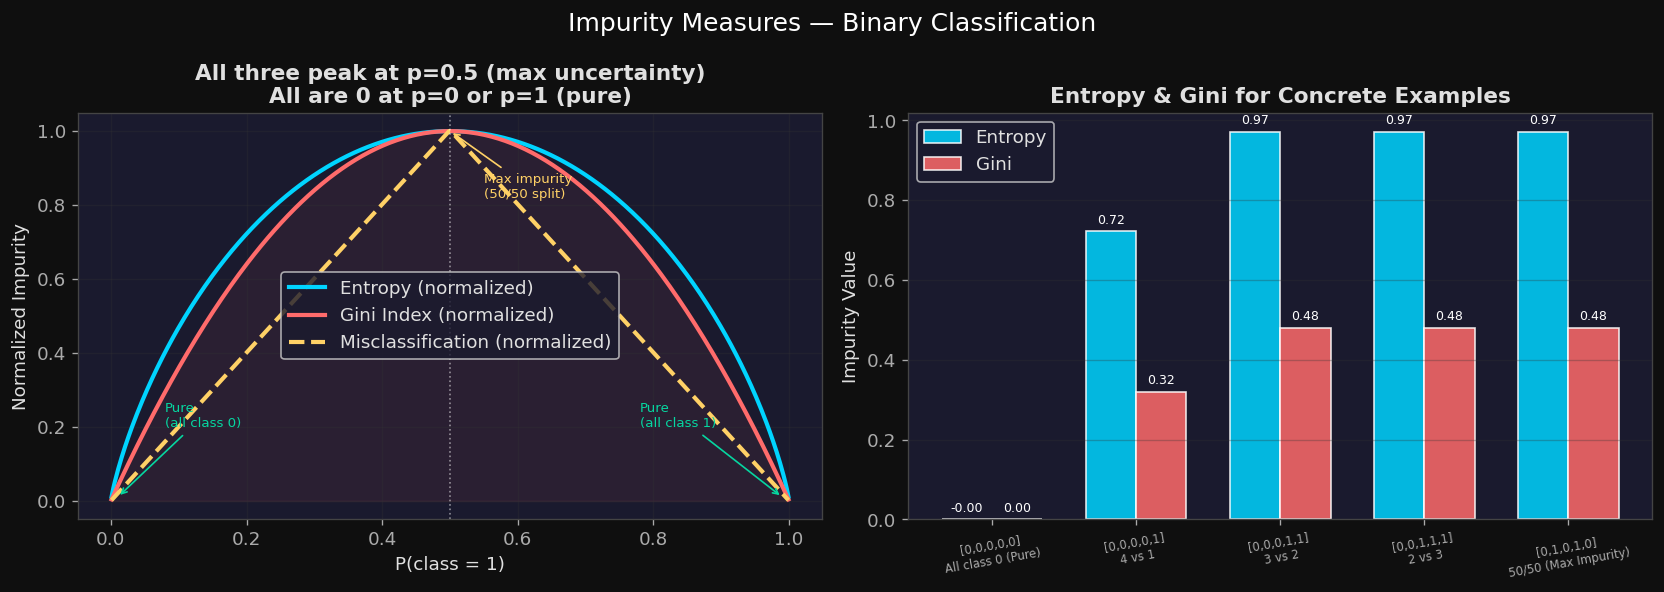

📊 Sanity checks:
   Pure  [0,0,0,0,0] → Entropy=-0.000, Gini=0.000
   Mixed [0,1,0,1,0] → Entropy=0.971, Gini=0.480

🔑 Gini is faster to compute (no log), Entropy gives slightly different splits.
   In practice both produce very similar trees.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
#  Implement and visualize impurity measures
# ─────────────────────────────────────────────────────────────────────────────

def entropy(y):
    """
    Shannon Entropy: H(S) = -Σ p_k * log2(p_k)
    Range: [0, log2(K)] — 0 means pure, max means perfectly mixed
    """
    n = len(y)
    if n == 0:
        return 0.0
    counts = np.bincount(y.astype(int))
    probs  = counts[counts > 0] / n  # only non-zero probabilities
    return -np.sum(probs * np.log2(probs))

def gini(y):
    """
    Gini Index: G(S) = 1 - Σ p_k²
    Range: [0, 1 - 1/K] — 0 means pure
    """
    n = len(y)
    if n == 0:
        return 0.0
    counts = np.bincount(y.astype(int))
    probs  = counts / n
    return 1 - np.sum(probs ** 2)

def misclassification_error(y):
    """
    Misclassification rate: 1 - max(p_k)
    """
    n = len(y)
    if n == 0:
        return 0.0
    counts = np.bincount(y.astype(int))
    return 1 - counts.max() / n


# ── Visualize all three for binary case (p = P(class=1))
p = np.linspace(0.001, 0.999, 400)   # P(class 1)

H  = -(p * np.log2(p) + (1-p) * np.log2(1-p))   # entropy (binary)
G  = 2 * p * (1 - p)                              # gini (binary: 1 - p² - (1-p)²)
ME = 1 - np.maximum(p, 1 - p)                     # misclassification error

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Impurity Measures — Binary Classification', fontsize=15, color='white')

# ── Plot 1: All three curves
ax = axes[0]
ax.plot(p, H/H.max(),  color=COLORS[0], lw=2.5, label='Entropy (normalized)')
ax.plot(p, G/G.max(),  color=COLORS[1], lw=2.5, label='Gini Index (normalized)')
ax.plot(p, ME/ME.max(),color=COLORS[2], lw=2.5, label='Misclassification (normalized)', ls='--')

ax.axvline(0.5, color='white', ls=':', lw=1, alpha=0.5)
ax.fill_between(p, 0, G/G.max(), alpha=0.07, color=COLORS[1])
ax.set_xlabel('P(class = 1)')
ax.set_ylabel('Normalized Impurity')
ax.set_title('All three peak at p=0.5 (max uncertainty)\nAll are 0 at p=0 or p=1 (pure)')
ax.legend()
ax.grid(True, alpha=0.3)

# Annotate pure/impure points
ax.annotate('Pure\n(all class 0)', (0.01, 0.01), xytext=(0.08, 0.2), fontsize=8,
            color=COLORS[3], arrowprops=dict(arrowstyle='->', color=COLORS[3]))
ax.annotate('Max impurity\n(50/50 split)', (0.5, 1.0), xytext=(0.55, 0.82), fontsize=8,
            color=COLORS[2], arrowprops=dict(arrowstyle='->', color=COLORS[2]))
ax.annotate('Pure\n(all class 1)', (0.99, 0.01), xytext=(0.78, 0.2), fontsize=8,
            color=COLORS[3], arrowprops=dict(arrowstyle='->', color=COLORS[3]))

# ── Plot 2: Concrete examples
ax2 = axes[1]
examples = [
    {'label': '[0,0,0,0,0]\nAll class 0 (Pure)',    'y': np.zeros(5)},
    {'label': '[0,0,0,0,1]\n4 vs 1',               'y': np.array([0,0,0,0,1])},
    {'label': '[0,0,0,1,1]\n3 vs 2',               'y': np.array([0,0,0,1,1])},
    {'label': '[0,0,1,1,1]\n2 vs 3',               'y': np.array([0,0,1,1,1])},
    {'label': '[0,1,0,1,0]\n50/50 (Max Impurity)', 'y': np.array([0,1,0,1,0])},
]

x_pos = np.arange(len(examples))
e_vals  = [entropy(ex['y']) for ex in examples]
g_vals  = [gini(ex['y'])    for ex in examples]

width = 0.35
bars1 = ax2.bar(x_pos - width/2, e_vals, width, color=COLORS[0], alpha=0.85, label='Entropy', edgecolor='white')
bars2 = ax2.bar(x_pos + width/2, g_vals, width, color=COLORS[1], alpha=0.85, label='Gini',    edgecolor='white')

for bar, val in zip(bars1, e_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{val:.2f}',
             ha='center', fontsize=7.5, color='white')
for bar, val in zip(bars2, g_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{val:.2f}',
             ha='center', fontsize=7.5, color='white')

ax2.set_xticks(x_pos)
ax2.set_xticklabels([ex['label'] for ex in examples], fontsize=7, rotation=10)
ax2.set_ylabel('Impurity Value')
ax2.set_title('Entropy & Gini for Concrete Examples')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Verify our functions
y_test_pure  = np.array([0,0,0,0,0])
y_test_mixed = np.array([0,1,0,1,0])
print("📊 Sanity checks:")
print(f"   Pure  [0,0,0,0,0] → Entropy={entropy(y_test_pure):.3f}, Gini={gini(y_test_pure):.3f}")
print(f"   Mixed [0,1,0,1,0] → Entropy={entropy(y_test_mixed):.3f}, Gini={gini(y_test_mixed):.3f}")
print()
print("🔑 Gini is faster to compute (no log), Entropy gives slightly different splits.")
print("   In practice both produce very similar trees.")

---
## Part 3 — Information Gain: Finding the Best Split

**Information Gain** measures how much a split *reduces* impurity:

$$\text{IG}(S, \text{split}) = \text{Impurity}(S) - \sum_{\text{child} \in \{L, R\}} \frac{|S_{\text{child}}|}{|S|} \cdot \text{Impurity}(S_{\text{child}})$$

- **Parent impurity:** how mixed the current node is
- **Weighted child impurity:** weighted average of children's impurity (larger children count more)
- **Information Gain:** the reduction — we want to **maximize** this

**Splitting process:**
1. For each feature $j$ and each possible threshold $t$: compute IG
2. Choose the $(j^*, t^*)$ pair that maximizes IG
3. Split data: left → $x_j \leq t^*$, right → $x_j > t^*$
4. Recurse on each child

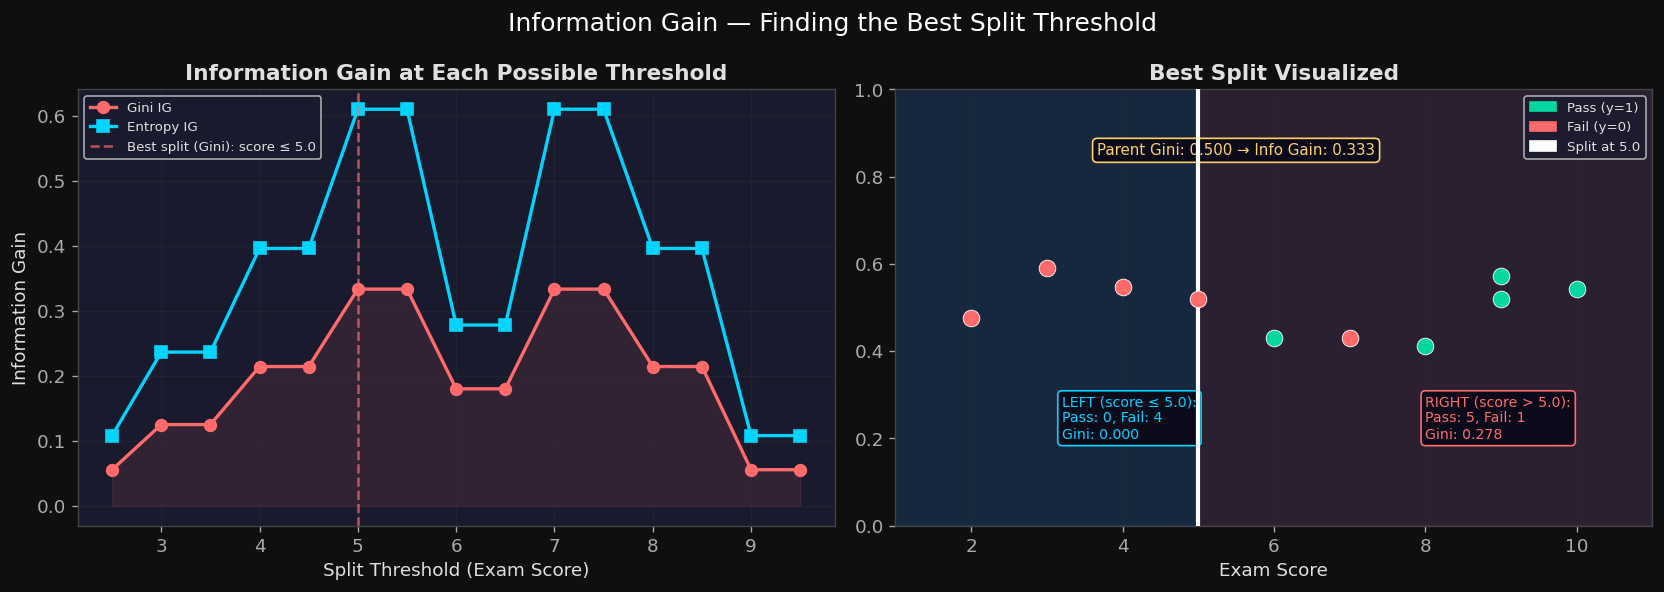


✅ Best split: score ≤ 5.0 gives IG = 0.3333


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
#  Information Gain — step-by-step visual
# ─────────────────────────────────────────────────────────────────────────────

def information_gain(y_parent, y_left, y_right, criterion='gini'):
    """
    Compute Information Gain of a split.
    IG = Impurity(parent) - weighted_avg(Impurity(children))
    """
    impurity_fn = gini if criterion == 'gini' else entropy
    
    n  = len(y_parent)
    nL = len(y_left)
    nR = len(y_right)
    
    parent_impurity    = impurity_fn(y_parent)
    weighted_child_imp = (nL/n) * impurity_fn(y_left) + (nR/n) * impurity_fn(y_right)
    
    return parent_impurity - weighted_child_imp


# ── Concrete example: 10 samples, split at different thresholds
# Feature: exam score (0-10). Label: Pass(1)/Fail(0)
scores = np.array([2, 3, 4, 5, 6, 7, 8, 9, 9, 10], dtype=float)
labels = np.array([0, 0, 0, 0, 1, 0, 1, 1, 1,  1],  dtype=int)

thresholds = np.arange(2.5, 10, 0.5)
ig_gini    = []
ig_entropy = []

for t in thresholds:
    left  = labels[scores <= t]
    right = labels[scores  > t]
    if len(left) == 0 or len(right) == 0:
        ig_gini.append(0); ig_entropy.append(0)
        continue
    ig_gini.append(information_gain(labels, left, right, 'gini'))
    ig_entropy.append(information_gain(labels, left, right, 'entropy'))

best_t_gini = thresholds[np.argmax(ig_gini)]
best_t_entr = thresholds[np.argmax(ig_entropy)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Information Gain — Finding the Best Split Threshold', fontsize=15, color='white')

# ── Plot 1: IG vs threshold
ax = axes[0]
ax.plot(thresholds, ig_gini,    'o-', color=COLORS[1], lw=2, ms=7, label='Gini IG')
ax.plot(thresholds, ig_entropy, 's-', color=COLORS[0], lw=2, ms=7, label='Entropy IG')
ax.axvline(best_t_gini, color=COLORS[1], ls='--', lw=1.5, alpha=0.7,
            label=f'Best split (Gini): score ≤ {best_t_gini}')
ax.fill_between(thresholds, 0, ig_gini, alpha=0.1, color=COLORS[1])
ax.set_xlabel('Split Threshold (Exam Score)')
ax.set_ylabel('Information Gain')
ax.set_title('Information Gain at Each Possible Threshold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Plot 2: Before and after best split
ax2 = axes[1]
t_best = best_t_gini
left_mask  = scores <= t_best
right_mask = scores  > t_best

y_pos_pass = 1
y_pos_fail = 0

# Before split
for i, (s, l) in enumerate(zip(scores, labels)):
    col = COLORS[3] if l == 1 else COLORS[1]
    ax2.scatter(s, 0.5 + np.random.uniform(-0.1, 0.1), color=col, s=100, zorder=5, edgecolors='white', lw=0.5)

ax2.axvline(t_best, color='white', lw=2.5, ls='-', zorder=4, label=f'Split: score ≤ {t_best}')
ax2.fill_betweenx([0, 1], 0, t_best, alpha=0.08, color=COLORS[0])
ax2.fill_betweenx([0, 1], t_best, 11, alpha=0.08, color=COLORS[1])

# Annotations
left_labels  = labels[left_mask]
right_labels = labels[right_mask]
ig_best = information_gain(labels, left_labels, right_labels, 'gini')

ax2.text(3.2, 0.2, f'LEFT (score ≤ {t_best}):\n'
         f'Pass: {left_labels.sum()}, Fail: {(1-left_labels).sum()}\n'
         f'Gini: {gini(left_labels):.3f}',
         fontsize=8.5, color=COLORS[0],
         bbox=dict(facecolor='#0a0a1a', edgecolor=COLORS[0], boxstyle='round,pad=0.3'))
ax2.text(8.0, 0.2, f'RIGHT (score > {t_best}):\n'
         f'Pass: {right_labels.sum()}, Fail: {(1-right_labels).sum()}\n'
         f'Gini: {gini(right_labels):.3f}',
         fontsize=8.5, color=COLORS[1],
         bbox=dict(facecolor='#0a0a1a', edgecolor=COLORS[1], boxstyle='round,pad=0.3'))

ax2.text(5.5, 0.85, f'Parent Gini: {gini(labels):.3f} → Info Gain: {ig_best:.3f}',
         ha='center', fontsize=9, color=COLORS[2],
         bbox=dict(facecolor='#0a0a1a', edgecolor=COLORS[2], boxstyle='round,pad=0.3'))

ax2.set_xlim(1, 11)
ax2.set_ylim(0, 1)
ax2.set_xlabel('Exam Score')
ax2.set_title('Best Split Visualized')
legend_patches = [mpatches.Patch(color=COLORS[3], label='Pass (y=1)'),
                  mpatches.Patch(color=COLORS[1], label='Fail (y=0)')]
ax2.legend(handles=legend_patches + [mpatches.Patch(color='white', label=f'Split at {t_best}')], fontsize=8)
ax2.grid(True, alpha=0.2, axis='x')

plt.tight_layout()
plt.show()
print(f"\n✅ Best split: score ≤ {t_best} gives IG = {ig_best:.4f}")

---
## Part 4 — The CART Algorithm

**CART** (Classification and Regression Trees) is the workhorse algorithm:

```
function BUILD_TREE(data, depth):
    if stopping_condition_met:   ← pure node, max_depth, min_samples
        return LEAF(majority_class)
    
    best_feature, best_threshold = FIND_BEST_SPLIT(data)
    
    left_data  = data[feature ≤ threshold]
    right_data = data[feature  > threshold]
    
    left_child  = BUILD_TREE(left_data,  depth+1)
    right_child = BUILD_TREE(right_data, depth+1)
    
    return NODE(feature, threshold, left_child, right_child)
```

**Stopping conditions:**
- Node is **pure** (all same class)
- Reached **max_depth**
- Node has fewer than **min_samples_split** samples
- Information gain is 0 (can't improve)

**Leaf prediction:** majority class (classification) or mean value (regression)

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
#  DECISION TREE NODE — data structure
# ─────────────────────────────────────────────────────────────────────────────

class Node:
    """
    A single node in a Decision Tree.
    
    Internal node: has feature_idx, threshold, left, right
    Leaf node:     has value (prediction)
    """
    def __init__(self):
        # Split information (for internal nodes)
        self.feature_idx = None   # which feature to split on
        self.threshold   = None   # split threshold
        self.left        = None   # left subtree  (x[j] <= threshold)
        self.right       = None   # right subtree (x[j]  > threshold)
        
        # Prediction (for leaf nodes)
        self.value       = None   # majority class or mean value
        
        # Metadata (useful for analysis)
        self.impurity    = None   # impurity at this node
        self.n_samples   = None   # number of samples at this node
        self.depth       = None
    
    @property
    def is_leaf(self):
        return self.value is not None


print("✅ Node class defined.")
print("   is_leaf=True  → prediction node (has .value)")
print("   is_leaf=False → split node (has .feature_idx, .threshold, .left, .right)")

✅ Node class defined.
   is_leaf=True  → prediction node (has .value)
   is_leaf=False → split node (has .feature_idx, .threshold, .left, .right)


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
#  CLASSIFICATION DECISION TREE — Full implementation from scratch
# ─────────────────────────────────────────────────────────────────────────────

class DecisionTreeClassifier:
    """
    Binary/Multi-class Decision Tree Classifier from scratch.
    Uses the CART algorithm with Gini or Entropy criterion.
    
    Supports:
      - Gini and Entropy splitting criteria
      - max_depth, min_samples_split, min_samples_leaf controls
      - Feature importance computation
      - Tree structure printing
    """
    
    def __init__(self, criterion='gini', max_depth=None,
                 min_samples_split=2, min_samples_leaf=1,
                 max_features=None):
        """
        Parameters:
        -----------
        criterion         : 'gini' or 'entropy'
        max_depth         : Maximum tree depth (None = grow fully)
        min_samples_split : Min samples required to split a node
        min_samples_leaf  : Min samples required in each leaf
        max_features      : Number of features to consider per split
                            (None = all, useful for Random Forests)
        """
        self.criterion          = criterion
        self.max_depth          = max_depth
        self.min_samples_split  = min_samples_split
        self.min_samples_leaf   = min_samples_leaf
        self.max_features       = max_features
        
        self.root               = None
        self.n_features_        = None
        self.classes_           = None
        self.feature_importances_ = None
        self._importance_sums   = None

    # ── Impurity function ────────────────────────────────────────────────────
    def _impurity(self, y):
        if self.criterion == 'gini':
            return gini(y)
        else:
            return entropy(y)

    # ── Find the best split for a node ───────────────────────────────────────
    def _best_split(self, X, y):
        """
        Exhaustively search all features and thresholds.
        Returns: (best_feature_idx, best_threshold, best_ig)
        """
        m, n = X.shape
        best_ig        = -1
        best_feature   = None
        best_threshold = None
        parent_impurity = self._impurity(y)
        
        # Select feature subset (for Random Forest compatibility)
        feature_indices = np.arange(n)
        if self.max_features and self.max_features < n:
            feature_indices = np.random.choice(n, self.max_features, replace=False)
        
        for feat_idx in feature_indices:
            # All unique values of this feature are candidate thresholds
            thresholds = np.unique(X[:, feat_idx])
            
            for t in thresholds:
                left_mask  = X[:, feat_idx] <= t
                right_mask = ~left_mask
                
                nL, nR = left_mask.sum(), right_mask.sum()
                
                # Skip if split creates too-small leaves
                if nL < self.min_samples_leaf or nR < self.min_samples_leaf:
                    continue
                
                # Information Gain
                ig = parent_impurity - (
                    (nL/m) * self._impurity(y[left_mask]) +
                    (nR/m) * self._impurity(y[right_mask])
                )
                
                if ig > best_ig:
                    best_ig        = ig
                    best_feature   = feat_idx
                    best_threshold = t
        
        return best_feature, best_threshold, best_ig

    # ── Recursively grow the tree ─────────────────────────────────────────────
    def _grow_tree(self, X, y, depth=0):
        """
        Recursively build the tree using the CART algorithm.
        """
        node = Node()
        node.n_samples = len(y)
        node.impurity  = self._impurity(y)
        node.depth     = depth
        
        # ── Stopping conditions ────────────────────────────────────────────
        # 1. Only one class present (pure node)
        is_pure = len(np.unique(y)) == 1
        # 2. Reached max depth
        max_depth_reached = self.max_depth is not None and depth >= self.max_depth
        # 3. Too few samples to split
        too_small = len(y) < self.min_samples_split
        
        if is_pure or max_depth_reached or too_small:
            # Make a leaf: predict the majority class
            counts = np.bincount(y.astype(int), minlength=len(self.classes_))
            node.value = self.classes_[np.argmax(counts)]
            return node
        
        # ── Find best split ────────────────────────────────────────────────
        feat_idx, threshold, ig = self._best_split(X, y)
        
        if feat_idx is None or ig <= 0:
            # No beneficial split found → make leaf
            counts = np.bincount(y.astype(int), minlength=len(self.classes_))
            node.value = self.classes_[np.argmax(counts)]
            return node
        
        # ── Record split info ──────────────────────────────────────────────
        node.feature_idx = feat_idx
        node.threshold   = threshold
        
        # Track feature importance: impurity decrease weighted by sample fraction
        # (Breiman's definition used in sklearn)
        self._importance_sums[feat_idx] += ig * len(y)
        
        # ── Recurse on children ────────────────────────────────────────────
        left_mask  = X[:, feat_idx] <= threshold
        right_mask = ~left_mask
        
        node.left  = self._grow_tree(X[left_mask],  y[left_mask],  depth+1)
        node.right = self._grow_tree(X[right_mask], y[right_mask], depth+1)
        
        return node

    # ── Public API ────────────────────────────────────────────────────────────
    def fit(self, X, y):
        """
        Grow the decision tree on training data.
        """
        self.n_features_        = X.shape[1]
        self.classes_           = np.unique(y)
        self._importance_sums   = np.zeros(self.n_features_)
        
        self.root = self._grow_tree(X, y, depth=0)
        
        # Normalize feature importances
        total = self._importance_sums.sum()
        self.feature_importances_ = self._importance_sums / (total + 1e-10)
        
        return self

    def _predict_one(self, x, node):
        """Traverse the tree for a single sample."""
        if node.is_leaf:
            return node.value
        if x[node.feature_idx] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        """Predict class labels for all samples."""
        return np.array([self._predict_one(x, self.root) for x in X])

    def score(self, X, y):
        """Accuracy."""
        return np.mean(self.predict(X) == y)

    def get_depth(self, node=None):
        """Compute the actual depth of the tree."""
        if node is None:
            node = self.root
        if node.is_leaf:
            return 0
        return 1 + max(self.get_depth(node.left), self.get_depth(node.right))

    def get_n_leaves(self, node=None):
        """Count leaf nodes."""
        if node is None:
            node = self.root
        if node.is_leaf:
            return 1
        return self.get_n_leaves(node.left) + self.get_n_leaves(node.right)

    def print_tree(self, node=None, depth=0, feature_names=None):
        """Print an ASCII representation of the tree."""
        if node is None:
            node = self.root
        indent = '│   ' * depth
        if node.is_leaf:
            print(f"{indent}└── 🍃 Predict: class {node.value}  (n={node.n_samples})")
        else:
            fname = (feature_names[node.feature_idx]
                     if feature_names else f"X[{node.feature_idx}]")
            print(f"{indent}├── 🔀 {fname} ≤ {node.threshold:.4f}  "
                  f"[n={node.n_samples}, impurity={node.impurity:.3f}]")
            print(f"{indent}│   ├── YES:")
            self.print_tree(node.left,  depth+1, feature_names)
            print(f"{indent}│   └── NO:")
            self.print_tree(node.right, depth+1, feature_names)


print("✅ DecisionTreeClassifier defined!")
print("   Methods: fit(), predict(), score(), print_tree(), get_depth(), get_n_leaves()")

✅ DecisionTreeClassifier defined!
   Methods: fit(), predict(), score(), print_tree(), get_depth(), get_n_leaves()


---
## Part 5 — Training and Visualizing the Tree

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
#  Generate and split a 2D dataset
# ─────────────────────────────────────────────────────────────────────────────

def make_2d_data(n=300, kind='blobs', seed=42):
    rng = np.random.RandomState(seed)
    if kind == 'blobs':
        centers = [(-2, -2), (2, 2), (-2, 2)]
        X_list, y_list = [], []
        for i, (cx, cy) in enumerate(centers):
            n_i = n // len(centers)
            X_list.append(rng.randn(n_i, 2) * 0.9 + [cx, cy])
            y_list.append(np.full(n_i, i))
        X = np.vstack(X_list); y = np.hstack(y_list)
    elif kind == 'xor':
        X = rng.randn(n, 2)
        y = ((X[:, 0] > 0) ^ (X[:, 1] > 0)).astype(int)
    idx = rng.permutation(len(y))
    return X[idx], y[idx]

def train_test_split(X, y, test_size=0.2, seed=42):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(y))
    split = int(len(y) * (1 - test_size))
    return X[idx[:split]], X[idx[split:]], y[idx[:split]], y[idx[split:]]


X, y = make_2d_data(n=300, kind='blobs')
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Train tree with limited depth
tree = DecisionTreeClassifier(criterion='gini', max_depth=3)
tree.fit(X_train, y_train)

print(f"✅ Tree trained!")
print(f"   Depth:    {tree.get_depth()}")
print(f"   Leaves:   {tree.get_n_leaves()}")
print(f"   Train acc: {tree.score(X_train, y_train):.4f}")
print(f"   Test acc:  {tree.score(X_test, y_test):.4f}")

print("\n🌳 Tree Structure:")
print("="*55)
feature_names = ['Feature 1', 'Feature 2']
tree.print_tree(feature_names=feature_names)

✅ Tree trained!
   Depth:    3
   Leaves:   5
   Train acc: 0.9792
   Test acc:  1.0000

🌳 Tree Structure:
├── 🔀 Feature 2 ≤ -0.2929  [n=240, impurity=0.666]
│   ├── YES:
│   └── 🍃 Predict: class 0  (n=80)
│   └── NO:
│   ├── 🔀 Feature 1 ≤ -0.1453  [n=160, impurity=0.518]
│   │   ├── YES:
│   │   ├── 🔀 Feature 2 ≤ 0.4482  [n=83, impurity=0.093]
│   │   │   ├── YES:
│   │   │   └── 🍃 Predict: class 2  (n=8)
│   │   │   └── NO:
│   │   │   └── 🍃 Predict: class 2  (n=75)
│   │   └── NO:
│   │   ├── 🔀 Feature 1 ≤ 0.7710  [n=77, impurity=0.026]
│   │   │   ├── YES:
│   │   │   └── 🍃 Predict: class 1  (n=4)
│   │   │   └── NO:
│   │   │   └── 🍃 Predict: class 1  (n=73)


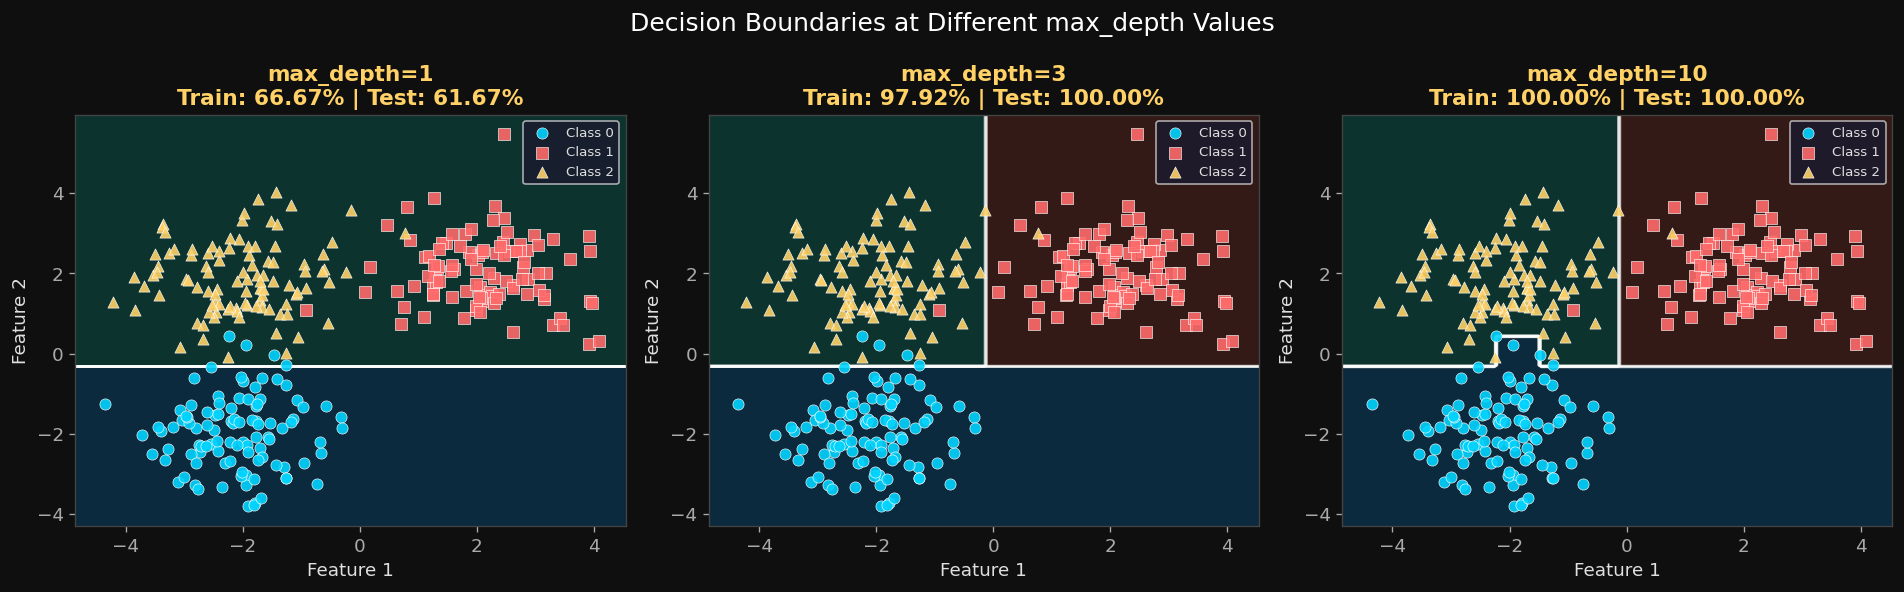

🔑 Key observations:
   depth=1  → underfitting (too simple, straight single cut)
   depth=3  → good balance (axis-aligned rectangular regions)
   depth=10 → overfitting (complex jagged boundaries, memorizes training noise)


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
#  Visualize decision boundary (axis-aligned splits = rectangular regions)
# ─────────────────────────────────────────────────────────────────────────────

def plot_decision_boundary_tree(model, X, y, title='', ax=None, h=0.05):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 6))
    
    x_min, x_max = X[:, 0].min()-0.5, X[:, 0].max()+0.5
    y_min, y_max = X[:, 1].min()-0.5, X[:, 1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    n_classes = len(np.unique(y))
    bg_colors = ['#003a4d', '#4d1a00', '#004d2e'][:n_classes]
    cmap_bg   = ListedColormap(bg_colors)
    ax.contourf(xx, yy, Z, alpha=0.5, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='white', linewidths=1.2, alpha=0.6)
    
    markers = ['o', 's', '^']
    class_labels = [f'Class {c}' for c in np.unique(y)]
    for cls, col, mk, lbl in zip(np.unique(y), COLORS, markers, class_labels):
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1], color=col, s=45,
                   edgecolors='white', lw=0.4, alpha=0.9, marker=mk,
                   label=lbl, zorder=5)
    
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
    ax.set_title(title, color=COLORS[2])
    ax.legend(fontsize=8)
    return ax


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Decision Boundaries at Different max_depth Values', fontsize=15, color='white')

for ax, depth in zip(axes, [1, 3, 10]):
    t = DecisionTreeClassifier(criterion='gini', max_depth=depth)
    t.fit(X_train, y_train)
    train_a = t.score(X_train, y_train)
    test_a  = t.score(X_test, y_test)
    plot_decision_boundary_tree(
        t, X, y,
        title=f'max_depth={depth}\nTrain: {train_a:.2%} | Test: {test_a:.2%}',
        ax=ax
    )

plt.tight_layout()
plt.show()

print("🔑 Key observations:")
print("   depth=1  → underfitting (too simple, straight single cut)")
print("   depth=3  → good balance (axis-aligned rectangular regions)")
print("   depth=10 → overfitting (complex jagged boundaries, memorizes training noise)")

---
## Part 6 — Visualizing the Tree as a Diagram

Let's render an actual tree diagram showing the splits, impurity, and sample counts at each node.

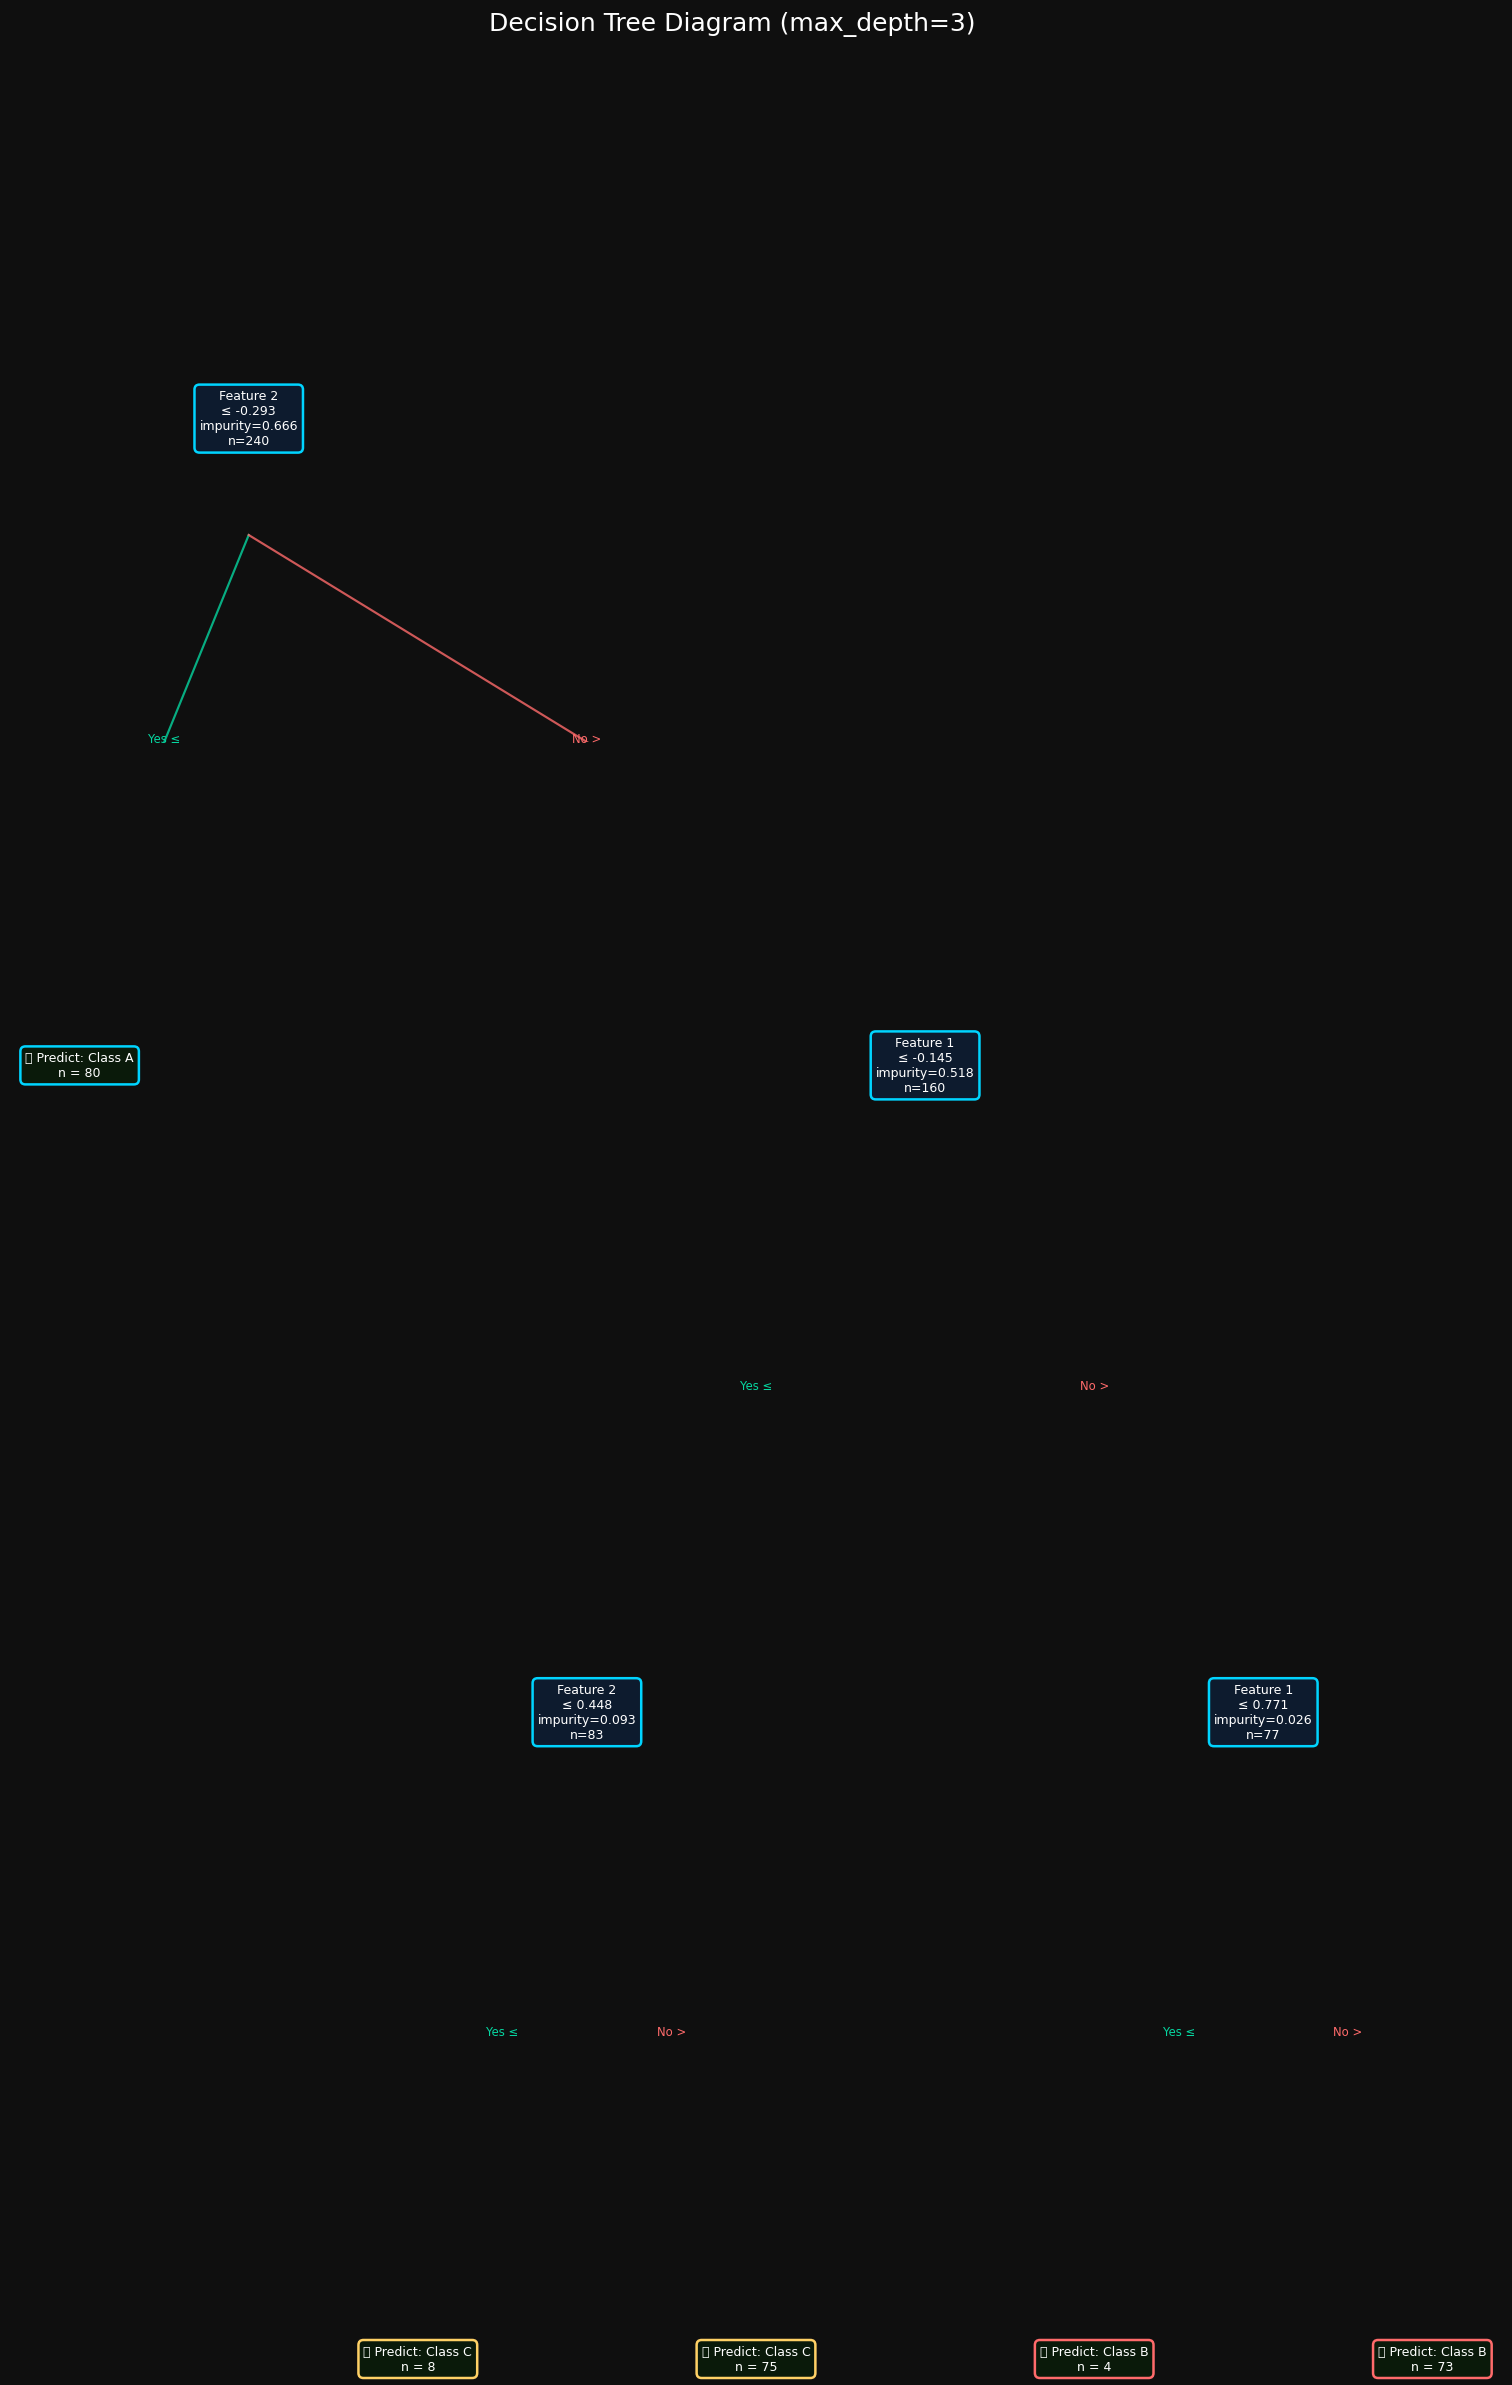

Tree has 5 leaves and depth 3


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
#  Draw the tree as a graphical diagram
# ─────────────────────────────────────────────────────────────────────────────

def draw_tree_diagram(root, feature_names=None, class_names=None,
                      figsize=(16, 8)):
    fig, ax = plt.subplots(figsize=figsize, facecolor='#0f0f0f')
    ax.set_facecolor('#0f0f0f')
    ax.axis('off')
    
    # We'll assign (x, y) positions to each node using DFS
    positions = {}
    counter   = [0]  # mutable for closure

    def assign_positions(node, depth):
        if node is None:
            return
        assign_positions(node.left,  depth + 1)
        node._plot_x = counter[0]
        counter[0]  += 1
        node._plot_y = -depth
        assign_positions(node.right, depth + 1)

    assign_positions(root, 0)
    total_nodes = counter[0]

    def draw_node_box(node):
        x, y = node._plot_x / max(total_nodes - 1, 1), node._plot_y
        
        if node.is_leaf:
            cls = node.value
            cname = (class_names[int(cls)] if class_names else f'class {int(cls)}')
            col   = COLORS[int(cls) % len(COLORS)]
            label = f"🍃 Predict: {cname}\nn = {node.n_samples}"
            facecolor = '#0a1a0a'
            edgecolor = col
        else:
            fname = (feature_names[node.feature_idx]
                     if feature_names else f'X[{node.feature_idx}]')
            label = (f"{fname}\n≤ {node.threshold:.3f}\n"
                     f"impurity={node.impurity:.3f}\nn={node.n_samples}")
            facecolor = '#0d1b2e'
            edgecolor = '#00d4ff'

        ax.text(x, y, label, ha='center', va='center', fontsize=7.5,
                color='white', multialignment='center',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=facecolor,
                          edgecolor=edgecolor, linewidth=1.5),
                zorder=5)
        return x, y

    def draw_edges(node):
        if node is None or node.is_leaf:
            return
        x_p, y_p = node._plot_x / max(total_nodes-1, 1), node._plot_y
        
        for child, label, col in [
            (node.left,  'Yes ≤', COLORS[3]),
            (node.right, 'No >',  COLORS[1])
        ]:
            if child:
                x_c, y_c = child._plot_x / max(total_nodes-1, 1), child._plot_y
                ax.plot([x_p, x_c], [y_p-0.18, y_c+0.18],
                        color=col, lw=1.3, alpha=0.8, zorder=3)
                mx, my = (x_p+x_c)/2, (y_p+y_c)/2
                ax.text(mx, my, label, ha='center', fontsize=7,
                        color=col, zorder=4)
            draw_edges(child)

    def draw_all_nodes(node):
        if node is None:
            return
        draw_node_box(node)
        draw_all_nodes(node.left)
        draw_all_nodes(node.right)

    draw_edges(root)
    draw_all_nodes(root)

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(root._plot_y - 0.5, 0.5)
    return fig, ax


# Train a small tree for clear visualization
tree_small = DecisionTreeClassifier(criterion='gini', max_depth=3)
tree_small.fit(X_train, y_train)

fig, ax = draw_tree_diagram(
    tree_small.root,
    feature_names=['Feature 1', 'Feature 2'],
    class_names=['Class A', 'Class B', 'Class C'],
    figsize=(16, 7)
)
fig.suptitle('Decision Tree Diagram (max_depth=3)', fontsize=15, color='white')
plt.tight_layout()
plt.show()
print(f"Tree has {tree_small.get_n_leaves()} leaves and depth {tree_small.get_depth()}")

---
## Part 7 — Regression Trees

Decision Trees can also predict **continuous values** — this is a **Regression Tree**.

Key differences from Classification Trees:

| | Classification Tree | Regression Tree |
|-|--------------------|-----------------|
| **Impurity measure** | Gini / Entropy | Variance (MSE) |
| **Leaf prediction** | Majority class | Mean of samples |
| **Splitting goal** | Maximize Info Gain | Minimize Variance |

**Variance reduction (splitting criterion for regression):**
$$\text{VarRed}(S, \text{split}) = \text{Var}(S) - \left[\frac{n_L}{n}\text{Var}(S_L) + \frac{n_R}{n}\text{Var}(S_R)\right]$$

**Leaf prediction:**
$$\hat{y}_{\text{leaf}} = \frac{1}{|S_{\text{leaf}}|} \sum_{i \in S_{\text{leaf}}} y_i$$

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
#  REGRESSION TREE — Full implementation from scratch
# ─────────────────────────────────────────────────────────────────────────────

class DecisionTreeRegressor:
    """
    Regression Decision Tree from scratch.
    Uses variance reduction as the splitting criterion.
    Leaf prediction = mean of target values in that leaf.
    """
    
    def __init__(self, max_depth=None, min_samples_split=2,
                 min_samples_leaf=1, max_features=None):
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf  = min_samples_leaf
        self.max_features      = max_features
        self.root              = None
        self.n_features_       = None
        self.feature_importances_ = None
        self._importance_sums  = None

    def _variance(self, y):
        """Variance of y — our impurity measure for regression."""
        if len(y) == 0:
            return 0.0
        return np.var(y)

    def _best_split(self, X, y):
        m, n = X.shape
        best_vr        = -1
        best_feature   = None
        best_threshold = None
        parent_var     = self._variance(y)
        
        feature_indices = np.arange(n)
        if self.max_features and self.max_features < n:
            feature_indices = np.random.choice(n, self.max_features, replace=False)
        
        for feat_idx in feature_indices:
            thresholds = np.unique(X[:, feat_idx])
            for t in thresholds:
                left_mask  = X[:, feat_idx] <= t
                right_mask = ~left_mask
                nL, nR = left_mask.sum(), right_mask.sum()
                if nL < self.min_samples_leaf or nR < self.min_samples_leaf:
                    continue
                # Variance reduction
                vr = parent_var - (
                    (nL/m) * self._variance(y[left_mask]) +
                    (nR/m) * self._variance(y[right_mask])
                )
                if vr > best_vr:
                    best_vr = vr; best_feature = feat_idx; best_threshold = t
        
        return best_feature, best_threshold, best_vr

    def _grow_tree(self, X, y, depth=0):
        node = Node()
        node.n_samples = len(y)
        node.impurity  = self._variance(y)
        node.depth     = depth
        
        # Stopping conditions
        if (len(y) < self.min_samples_split or
            (self.max_depth is not None and depth >= self.max_depth) or
            self._variance(y) < 1e-10):
            node.value = np.mean(y)  # ← leaf: predict mean
            return node
        
        feat_idx, threshold, vr = self._best_split(X, y)
        
        if feat_idx is None or vr <= 0:
            node.value = np.mean(y)
            return node
        
        node.feature_idx = feat_idx
        node.threshold   = threshold
        self._importance_sums[feat_idx] += vr * len(y)
        
        left_mask  = X[:, feat_idx] <= threshold
        right_mask = ~left_mask
        node.left  = self._grow_tree(X[left_mask],  y[left_mask],  depth+1)
        node.right = self._grow_tree(X[right_mask], y[right_mask], depth+1)
        return node

    def fit(self, X, y):
        self.n_features_      = X.shape[1]
        self._importance_sums = np.zeros(self.n_features_)
        self.root = self._grow_tree(X, y)
        total = self._importance_sums.sum()
        self.feature_importances_ = self._importance_sums / (total + 1e-10)
        return self

    def _predict_one(self, x, node):
        if node.is_leaf:
            return node.value
        if x[node.feature_idx] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])

    def score(self, X, y):
        """R² score."""
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        return 1 - ss_res / (ss_tot + 1e-10)

    def mse(self, X, y):
        return np.mean((self.predict(X) - y) ** 2)


print("✅ DecisionTreeRegressor defined!")
print("   Splitting criterion: Variance Reduction")
print("   Leaf prediction: mean(y in leaf)")

✅ DecisionTreeRegressor defined!
   Splitting criterion: Variance Reduction
   Leaf prediction: mean(y in leaf)


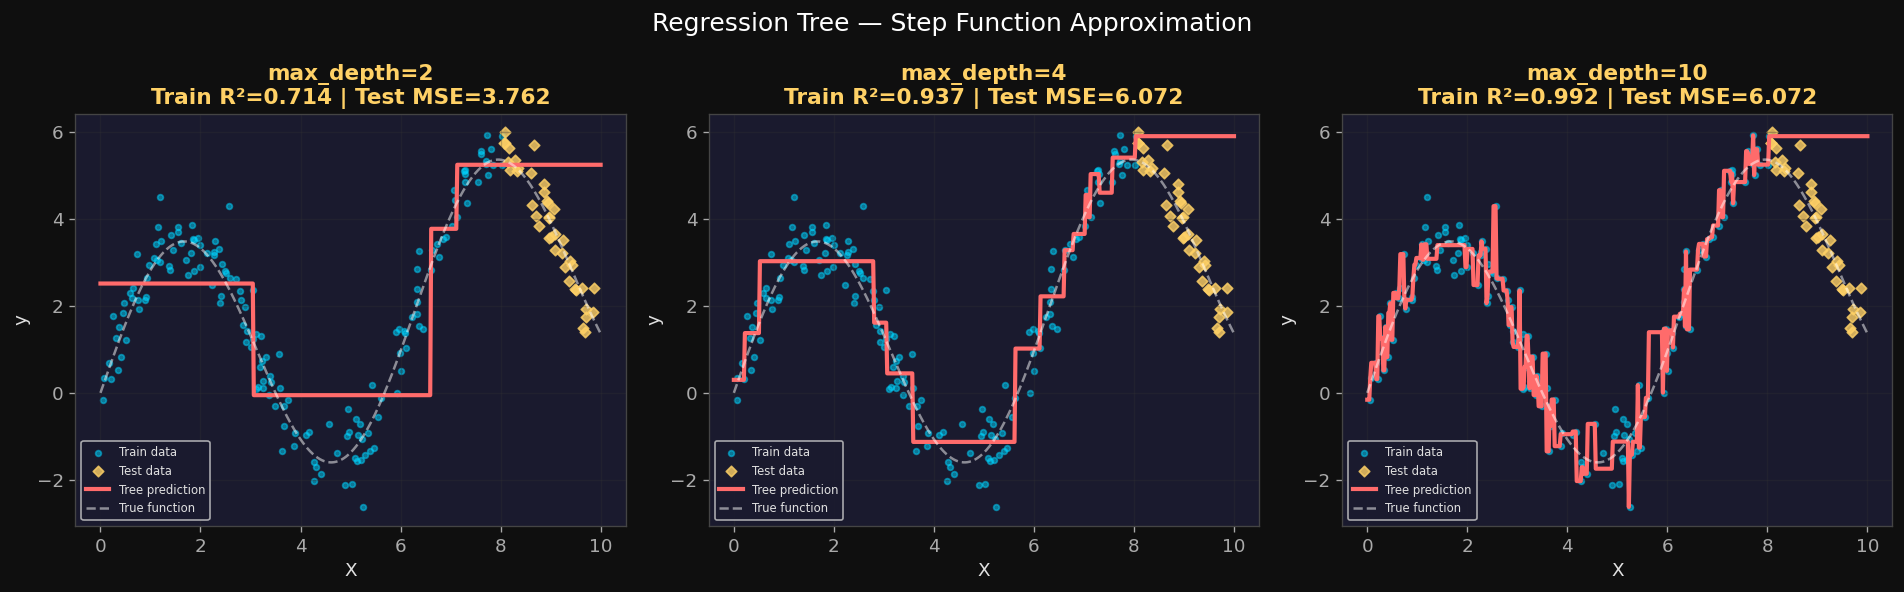

🔑 Regression trees create STEP FUNCTION approximations.
   More depth → finer steps → better fit but more overfitting risk.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
#  Visualize Regression Tree — step function approximation
# ─────────────────────────────────────────────────────────────────────────────

# Generate 1D regression data
rng = np.random.RandomState(42)
X_reg = np.sort(rng.uniform(0, 10, 200)).reshape(-1, 1)
y_reg = np.sin(X_reg.ravel()) * 3 + X_reg.ravel() * 0.3 + rng.randn(200) * 0.5

X_reg_tr, X_reg_te = X_reg[:160], X_reg[160:]
y_reg_tr, y_reg_te = y_reg[:160], y_reg[160:]

X_plot = np.linspace(0, 10, 500).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Regression Tree — Step Function Approximation', fontsize=15, color='white')

for ax, depth in zip(axes, [2, 4, 10]):
    reg_tree = DecisionTreeRegressor(max_depth=depth)
    reg_tree.fit(X_reg_tr, y_reg_tr)
    y_plot = reg_tree.predict(X_plot)
    
    train_r2 = reg_tree.score(X_reg_tr, y_reg_tr)
    test_mse = reg_tree.mse(X_reg_te, y_reg_te)
    
    ax.scatter(X_reg_tr, y_reg_tr, color=COLORS[0], s=12, alpha=0.5, label='Train data')
    ax.scatter(X_reg_te, y_reg_te, color=COLORS[2], s=20, alpha=0.8, marker='D', label='Test data')
    ax.plot(X_plot, y_plot, color=COLORS[1], lw=2.5, label='Tree prediction')
    
    # True underlying function
    y_true = np.sin(X_plot.ravel()) * 3 + X_plot.ravel() * 0.3
    ax.plot(X_plot, y_true, color='white', lw=1.5, ls='--', alpha=0.5, label='True function')
    
    ax.set_title(f'max_depth={depth}\nTrain R²={train_r2:.3f} | Test MSE={test_mse:.3f}',
                 color=COLORS[2])
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🔑 Regression trees create STEP FUNCTION approximations.")
print("   More depth → finer steps → better fit but more overfitting risk.")

---
## Part 8 — Overfitting and the Bias-Variance Tradeoff

Decision Trees are **high-variance** models — they can perfectly memorize training data.

**Bias-Variance Tradeoff:**
$$\text{Expected Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

- **Shallow tree:** High bias, low variance (underfitting)
- **Deep tree:** Low bias, high variance (overfitting)
- **Optimal depth:** Sweet spot in between

**Ways to control complexity:**
1. `max_depth` — most common control
2. `min_samples_split` — don't split if too few samples
3. `min_samples_leaf` — ensure leaves have minimum samples
4. **Post-pruning** — grow full tree, then remove leaves that don't improve validation performance

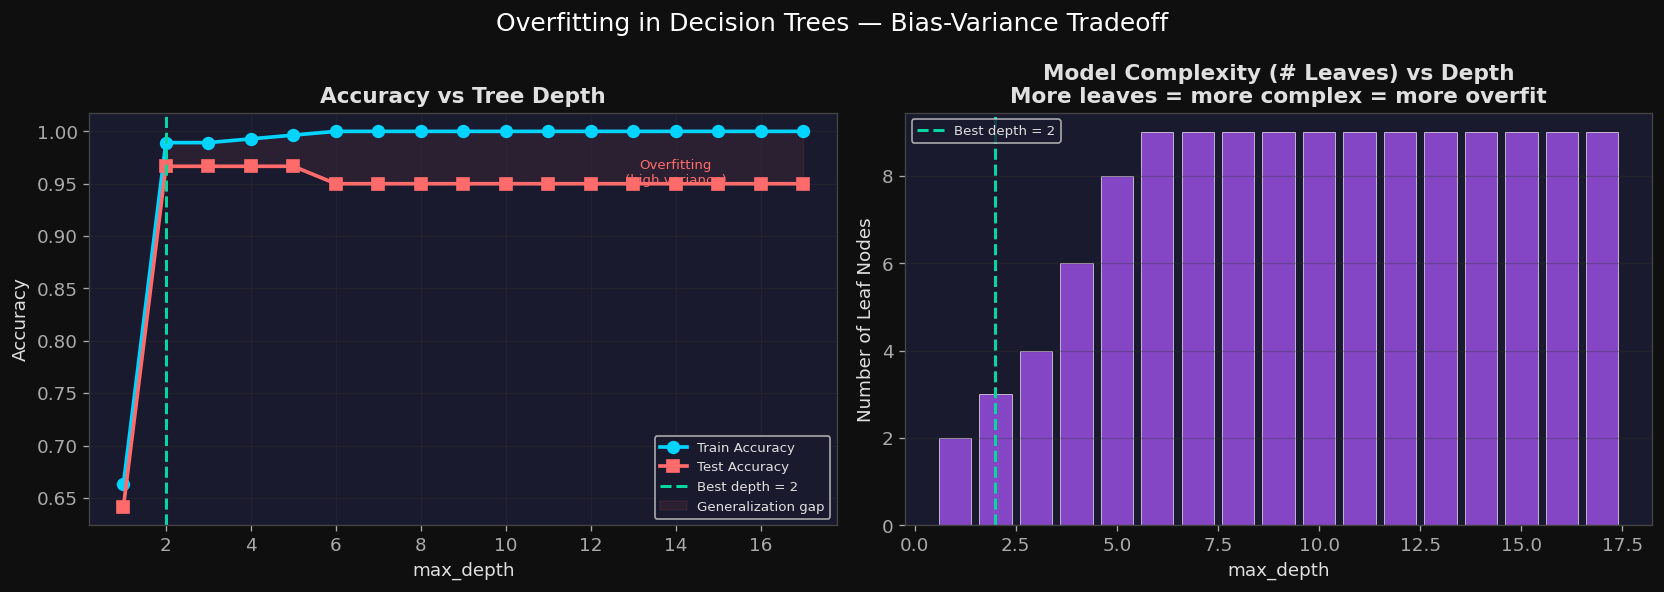


🎯 Best test accuracy at depth = 2
   Train acc: 0.9892
   Test acc:  0.9667


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
#  Bias-Variance visualization: train vs test accuracy across depths
# ─────────────────────────────────────────────────────────────────────────────

X_bv, y_bv = make_2d_data(n=400, kind='blobs')
X_bv_tr, X_bv_te, y_bv_tr, y_bv_te = train_test_split(X_bv, y_bv, test_size=0.3)

depths      = list(range(1, 18))
train_accs  = []
test_accs   = []
n_leaves    = []

for d in depths:
    t = DecisionTreeClassifier(criterion='gini', max_depth=d)
    t.fit(X_bv_tr, y_bv_tr)
    train_accs.append(t.score(X_bv_tr, y_bv_tr))
    test_accs.append(t.score(X_bv_te, y_bv_te))
    n_leaves.append(t.get_n_leaves())

best_depth = depths[np.argmax(test_accs)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Overfitting in Decision Trees — Bias-Variance Tradeoff', fontsize=15, color='white')

ax = axes[0]
ax.plot(depths, train_accs, 'o-', color=COLORS[0], lw=2.2, ms=7, label='Train Accuracy')
ax.plot(depths, test_accs,  's-', color=COLORS[1], lw=2.2, ms=7, label='Test Accuracy')
ax.axvline(best_depth, color=COLORS[3], ls='--', lw=1.8, label=f'Best depth = {best_depth}')
ax.fill_between(depths, train_accs, test_accs, alpha=0.08, color=COLORS[1],
                label='Generalization gap')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Tree Depth')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Annotate regions
ax.annotate('Underfitting\n(high bias)', (1.5, train_accs[0]-0.04),
            fontsize=8, color=COLORS[0], ha='center')
ax.annotate('Overfitting\n(high variance)', (14, test_accs[-3]),
            fontsize=8, color=COLORS[1], ha='center')

# Number of leaves
ax2 = axes[1]
ax2.bar(depths, n_leaves, color=COLORS[4], alpha=0.75, edgecolor='white', lw=0.5)
ax2.axvline(best_depth, color=COLORS[3], ls='--', lw=1.8, label=f'Best depth = {best_depth}')
ax2.set_xlabel('max_depth')
ax2.set_ylabel('Number of Leaf Nodes')
ax2.set_title('Model Complexity (# Leaves) vs Depth\nMore leaves = more complex = more overfit')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n🎯 Best test accuracy at depth = {best_depth}")
print(f"   Train acc: {train_accs[best_depth-1]:.4f}")
print(f"   Test acc:  {test_accs[best_depth-1]:.4f}")

---
## Part 9 — Feature Importance

Decision Trees naturally give us **feature importance scores** — which features are most useful for prediction?

**Gini Importance (Mean Decrease in Impurity):**
$$\text{Importance}(j) = \sum_{\text{nodes } t \text{ splitting on } j} \frac{n_t}{n} \cdot \text{IG}(t)$$

- Sum of impurity reductions caused by feature $j$, **weighted by sample fraction**
- Higher = more important
- Normalized to sum to 1

**Intuition:** A feature that creates large purity gains in nodes with many samples is very important.

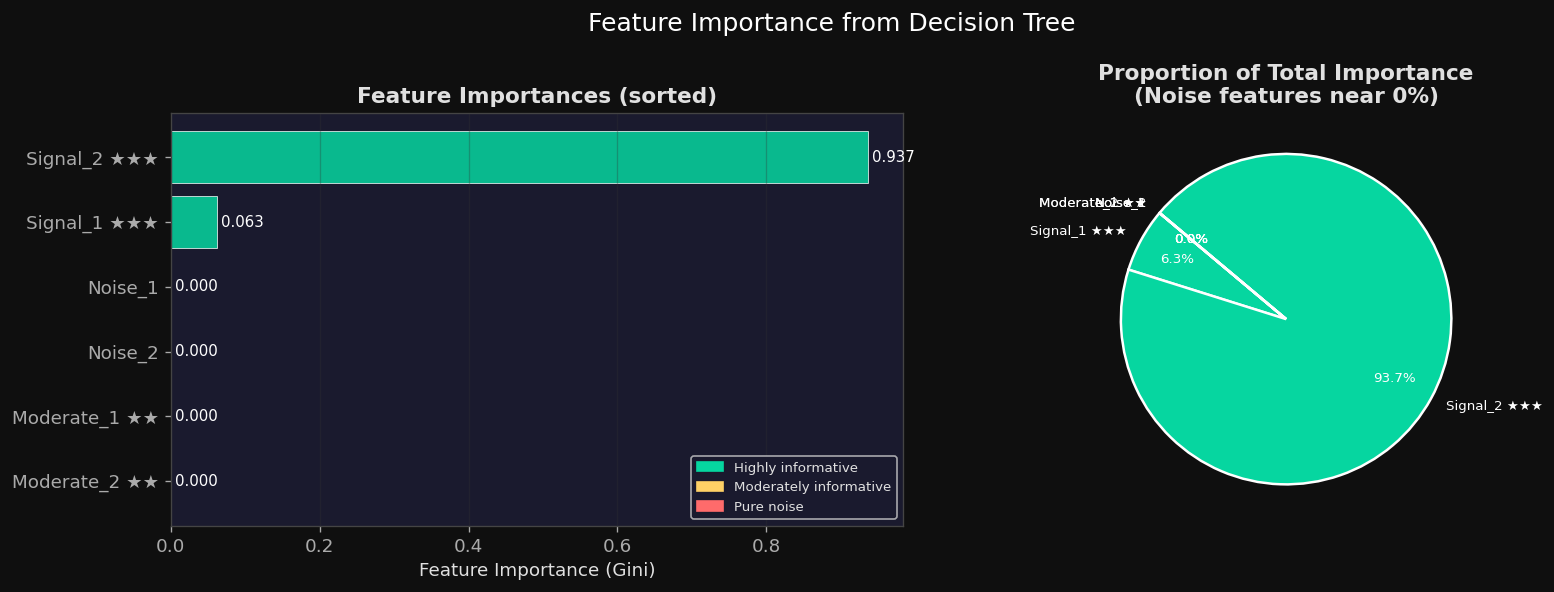

📊 Feature Importances:
  Signal_2 ★★★         ████████████████████████████ 0.9373
  Signal_1 ★★★         █                    0.0627
  Noise_1                                   0.0000
  Noise_2                                   0.0000
  Moderate_1 ★★                             0.0000
  Moderate_2 ★★                             0.0000

✅ Noise features correctly get near-zero importance!
   Test accuracy: 1.0000


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
#  Feature importance on a multi-feature dataset
# ─────────────────────────────────────────────────────────────────────────────

def make_multifeature_data(n=500, seed=42):
    """
    Create a dataset where features have KNOWN importance:
    - Feature 0,1: HIGHLY informative (determine class)
    - Feature 2,3: MODERATELY informative
    - Feature 4,5: NOISE (random, no useful signal)
    """
    rng = np.random.RandomState(seed)
    
    # Base signal features
    X0 = rng.randn(n//2, 2) + [-2, -2]
    X1 = rng.randn(n//2, 2) + [ 2,  2]
    X_signal = np.vstack([X0, X1])
    
    # Moderate features (correlated with signal + noise)
    X_mod = X_signal * 0.6 + rng.randn(n, 2) * 1.5
    
    # Pure noise features
    X_noise = rng.randn(n, 2) * 3
    
    X = np.hstack([X_signal, X_mod, X_noise])
    y = np.hstack([np.zeros(n//2), np.ones(n//2)])
    
    idx = rng.permutation(n)
    return X[idx], y[idx]


feat_names = ['Signal_1 ★★★', 'Signal_2 ★★★',
              'Moderate_1 ★★', 'Moderate_2 ★★',
              'Noise_1', 'Noise_2']

X_mf, y_mf = make_multifeature_data(n=500)
X_mf_tr, X_mf_te, y_mf_tr, y_mf_te = train_test_split(X_mf, y_mf)

tree_mf = DecisionTreeClassifier(criterion='gini', max_depth=5)
tree_mf.fit(X_mf_tr, y_mf_tr)

importances = tree_mf.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Importance from Decision Tree', fontsize=15, color='white')

# Bar chart
ax = axes[0]
colors_imp = [COLORS[3], COLORS[3], COLORS[2], COLORS[2], COLORS[1], COLORS[1]]
bars = ax.barh([feat_names[i] for i in sorted_idx[::-1]],
                importances[sorted_idx[::-1]],
                color=[colors_imp[i] for i in sorted_idx[::-1]],
                alpha=0.85, edgecolor='white', lw=0.5)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importances (sorted)')
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, importances[sorted_idx[::-1]]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, color='white')

# Legend
legend_items = [
    mpatches.Patch(color=COLORS[3], label='Highly informative'),
    mpatches.Patch(color=COLORS[2], label='Moderately informative'),
    mpatches.Patch(color=COLORS[1], label='Pure noise'),
]
ax.legend(handles=legend_items, fontsize=8)

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    importances,
    labels=feat_names,
    autopct='%1.1f%%',
    colors=colors_imp,
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for t in texts + autotexts:
    t.set_color('white')
    t.set_fontsize(8)
ax2.set_title('Proportion of Total Importance\n(Noise features near 0%)')

plt.tight_layout()
plt.show()

print("📊 Feature Importances:")
for i in sorted_idx:
    bar = '█' * int(importances[i] * 30)
    print(f"  {feat_names[i]:<20} {bar:<20} {importances[i]:.4f}")
print(f"\n✅ Noise features correctly get near-zero importance!")
print(f"   Test accuracy: {tree_mf.score(X_mf_te, y_mf_te):.4f}")

---
## Part 10 — XOR Problem: Where Trees Shine (vs. Logistic Regression)

Logistic regression can only create **linear boundaries**. 
Decision trees create **rectangular, non-linear boundaries** — perfect for XOR-like patterns.

The **XOR problem:** class = 1 if exactly one of (x₁ > 0, x₂ > 0) is true
- No straight line can separate these classes
- But a depth-2 tree can solve it perfectly!

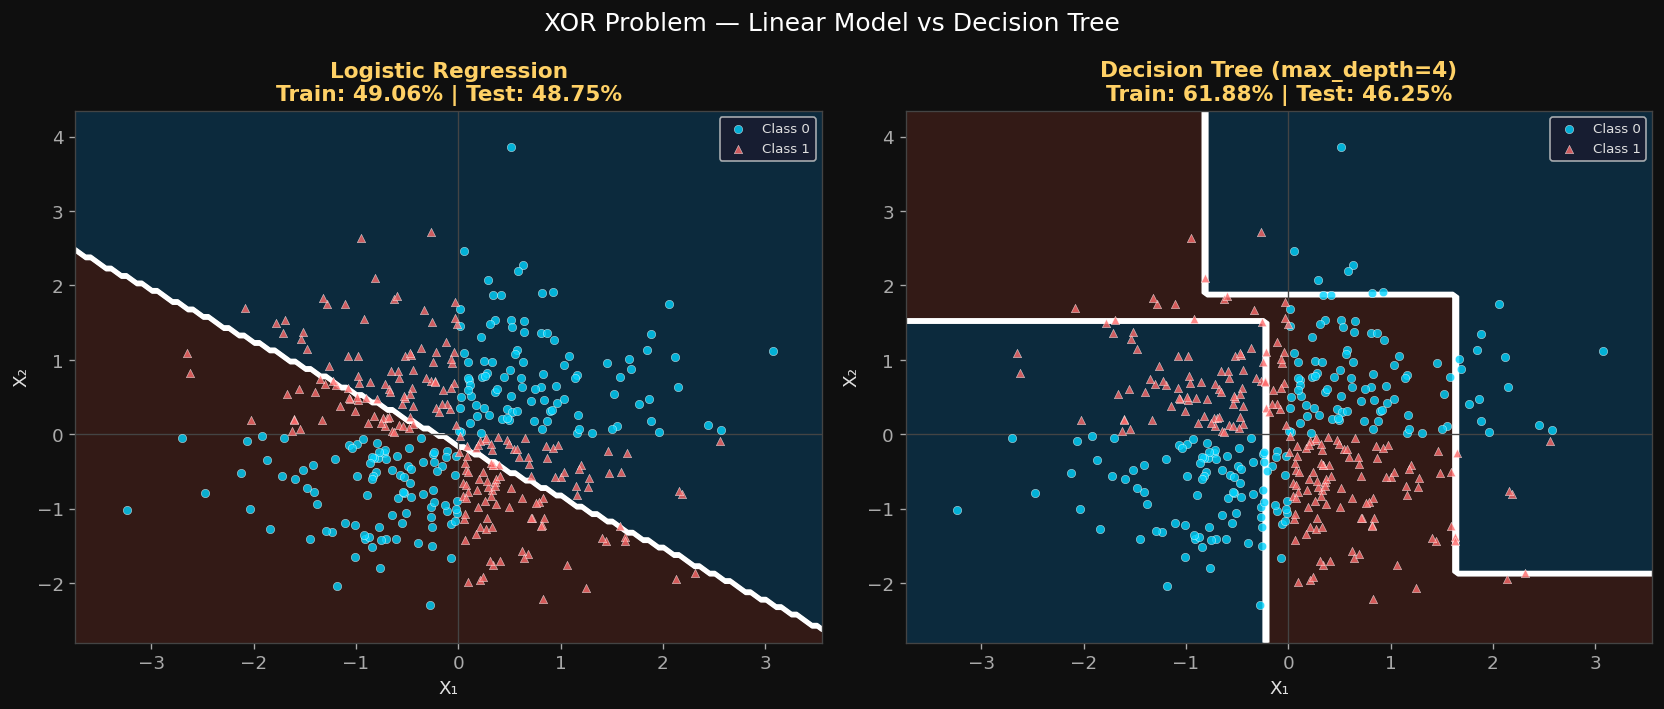

🔑 Logistic regression fails XOR — it can only create linear boundaries.
   Decision tree nails it — splits on X₁=0, then X₂=0 is enough.


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
#  XOR Problem: Decision Tree vs. Linear classifier
# ─────────────────────────────────────────────────────────────────────────────

X_xor, y_xor = make_2d_data(n=400, kind='xor')
X_xor_tr, X_xor_te, y_xor_tr, y_xor_te = train_test_split(X_xor, y_xor)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('XOR Problem — Linear Model vs Decision Tree', fontsize=15, color='white')

# ── Linear baseline (logistic regression)
from numpy.linalg import lstsq

class SimpleLogistic:
    """Minimal logistic regression for comparison."""
    def __init__(self, lr=0.1, n_iter=500):
        self.lr = lr; self.n_iter = n_iter
        self.w = None; self.b = 0
    def _sigmoid(self, z):
        return 1/(1+np.exp(-np.clip(z,-500,500)))
    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for _ in range(self.n_iter):
            p = self._sigmoid(X @ self.w + self.b)
            e = p - y
            self.w -= self.lr * (X.T @ e) / len(y)
            self.b -= self.lr * e.mean()
    def predict(self, X):
        return (self._sigmoid(X @ self.w + self.b) >= 0.5).astype(int)
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

log_model = SimpleLogistic(lr=0.5, n_iter=1000)
log_model.fit(X_xor_tr, y_xor_tr)

tree_xor = DecisionTreeClassifier(criterion='gini', max_depth=4)
tree_xor.fit(X_xor_tr, y_xor_tr)

h = 0.05
x_min, x_max = X_xor[:,0].min()-0.5, X_xor[:,0].max()+0.5
y_min, y_max = X_xor[:,1].min()-0.5, X_xor[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]

for ax, model, title, model_type in zip(
    axes,
    [log_model, tree_xor],
    ['Logistic Regression', 'Decision Tree (max_depth=4)'],
    ['logistic', 'tree']
):
    Z = model.predict(grid).reshape(xx.shape)
    cmap = ListedColormap(['#003a4d', '#4d1a00'])
    ax.contourf(xx, yy, Z, alpha=0.5, cmap=cmap)
    ax.contour(xx, yy, Z, colors='white', linewidths=1.5)
    
    for cls, col, mk in [(0, COLORS[0], 'o'), (1, COLORS[1], '^')]:
        mask = y_xor == cls
        ax.scatter(X_xor[mask, 0], X_xor[mask, 1], color=col, s=25,
                   edgecolors='white', lw=0.3, alpha=0.8, marker=mk,
                   label=f'Class {cls}', zorder=5)
    
    train_a = model.score(X_xor_tr, y_xor_tr)
    test_a  = model.score(X_xor_te, y_xor_te)
    ax.set_title(f'{title}\nTrain: {train_a:.2%} | Test: {test_a:.2%}', color=COLORS[2])
    ax.set_xlabel('X₁'); ax.set_ylabel('X₂')
    ax.legend(fontsize=8)
    ax.axhline(0, color='#444', lw=0.8)
    ax.axvline(0, color='#444', lw=0.8)

plt.tight_layout()
plt.show()

print("🔑 Logistic regression fails XOR — it can only create linear boundaries.")
print("   Decision tree nails it — splits on X₁=0, then X₂=0 is enough.")

---
## Part 11 — Full End-to-End Example: Medical Diagnosis

Let's apply everything on a realistic multi-feature clinical dataset — predicting heart disease risk.

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
#  Simulate heart disease dataset (based on Cleveland Heart Disease structure)
# ─────────────────────────────────────────────────────────────────────────────

def make_heart_disease_data(n=600, seed=42):
    rng = np.random.RandomState(seed)
    n0, n1 = int(n*0.55), int(n*0.45)
    
    # Feature: Age, Cholesterol, MaxHR, RestingBP, OldPeak, BloodSugar
    # Class 0 (no disease)
    X0 = rng.randn(n0, 6) * [8, 35, 18, 12, 0.8, 0.3] + [52, 215, 160, 125, 0.8, 0.2]
    # Class 1 (disease)
    X1 = rng.randn(n1, 6) * [9, 40, 15, 14, 1.2, 0.4] + [58, 260, 130, 140, 2.5, 0.5]
    
    X = np.vstack([X0, X1])
    y = np.hstack([np.zeros(n0), np.ones(n1)])
    idx = rng.permutation(n0+n1)
    return X[idx], y[idx]


heart_features = ['Age', 'Cholesterol', 'MaxHR', 'RestingBP', 'OldPeak', 'BloodSugar']

X_h, y_h = make_heart_disease_data(n=600)
X_h_tr, X_h_te, y_h_tr, y_h_te = train_test_split(X_h, y_h, test_size=0.2)

print(f"Dataset: {X_h.shape[0]} patients, {X_h.shape[1]} features")
print(f"Train: {len(X_h_tr)} | Test: {len(X_h_te)}")
print(f"Disease prevalence: {y_h.mean():.1%}")

# Train on several depths and pick best
best_depth_h, best_acc_h = 1, 0
for d in range(1, 12):
    t = DecisionTreeClassifier(criterion='gini', max_depth=d, min_samples_leaf=5)
    t.fit(X_h_tr, y_h_tr)
    acc = t.score(X_h_te, y_h_te)
    if acc > best_acc_h:
        best_acc_h, best_depth_h = acc, d

print(f"\nBest max_depth (by test accuracy): {best_depth_h}  (acc={best_acc_h:.4f})")

# Train final model
heart_tree = DecisionTreeClassifier(criterion='gini', max_depth=best_depth_h, min_samples_leaf=5)
heart_tree.fit(X_h_tr, y_h_tr)

y_pred_h = heart_tree.predict(X_h_te)

# Manual confusion matrix
def confusion_matrix(y_true, y_pred):
    TP = np.sum((y_pred==1) & (y_true==1))
    TN = np.sum((y_pred==0) & (y_true==0))
    FP = np.sum((y_pred==1) & (y_true==0))
    FN = np.sum((y_pred==0) & (y_true==1))
    return np.array([[TN, FP], [FN, TP]])

cm_h  = confusion_matrix(y_h_te, y_pred_h)
TN,FP,FN,TP = cm_h[0,0],cm_h[0,1],cm_h[1,0],cm_h[1,1]
prec  = TP/(TP+FP+1e-10)
rec   = TP/(TP+FN+1e-10)
f1    = 2*prec*rec/(prec+rec+1e-10)
spec  = TN/(TN+FP+1e-10)

print(f"\n📊 Heart Disease Prediction — Final Evaluation")
print("="*45)
print(f"  Accuracy    : {heart_tree.score(X_h_te, y_h_te):.4f}")
print(f"  Precision   : {prec:.4f}")
print(f"  Recall      : {rec:.4f}  (Sensitivity)")
print(f"  Specificity : {spec:.4f}")
print(f"  F1 Score    : {f1:.4f}")

Dataset: 600 patients, 6 features
Train: 480 | Test: 120
Disease prevalence: 45.0%



Best max_depth (by test accuracy): 6  (acc=0.8917)



📊 Heart Disease Prediction — Final Evaluation
  Accuracy    : 0.8917
  Precision   : 0.8364
  Recall      : 0.9200  (Sensitivity)
  Specificity : 0.8714
  F1 Score    : 0.8762


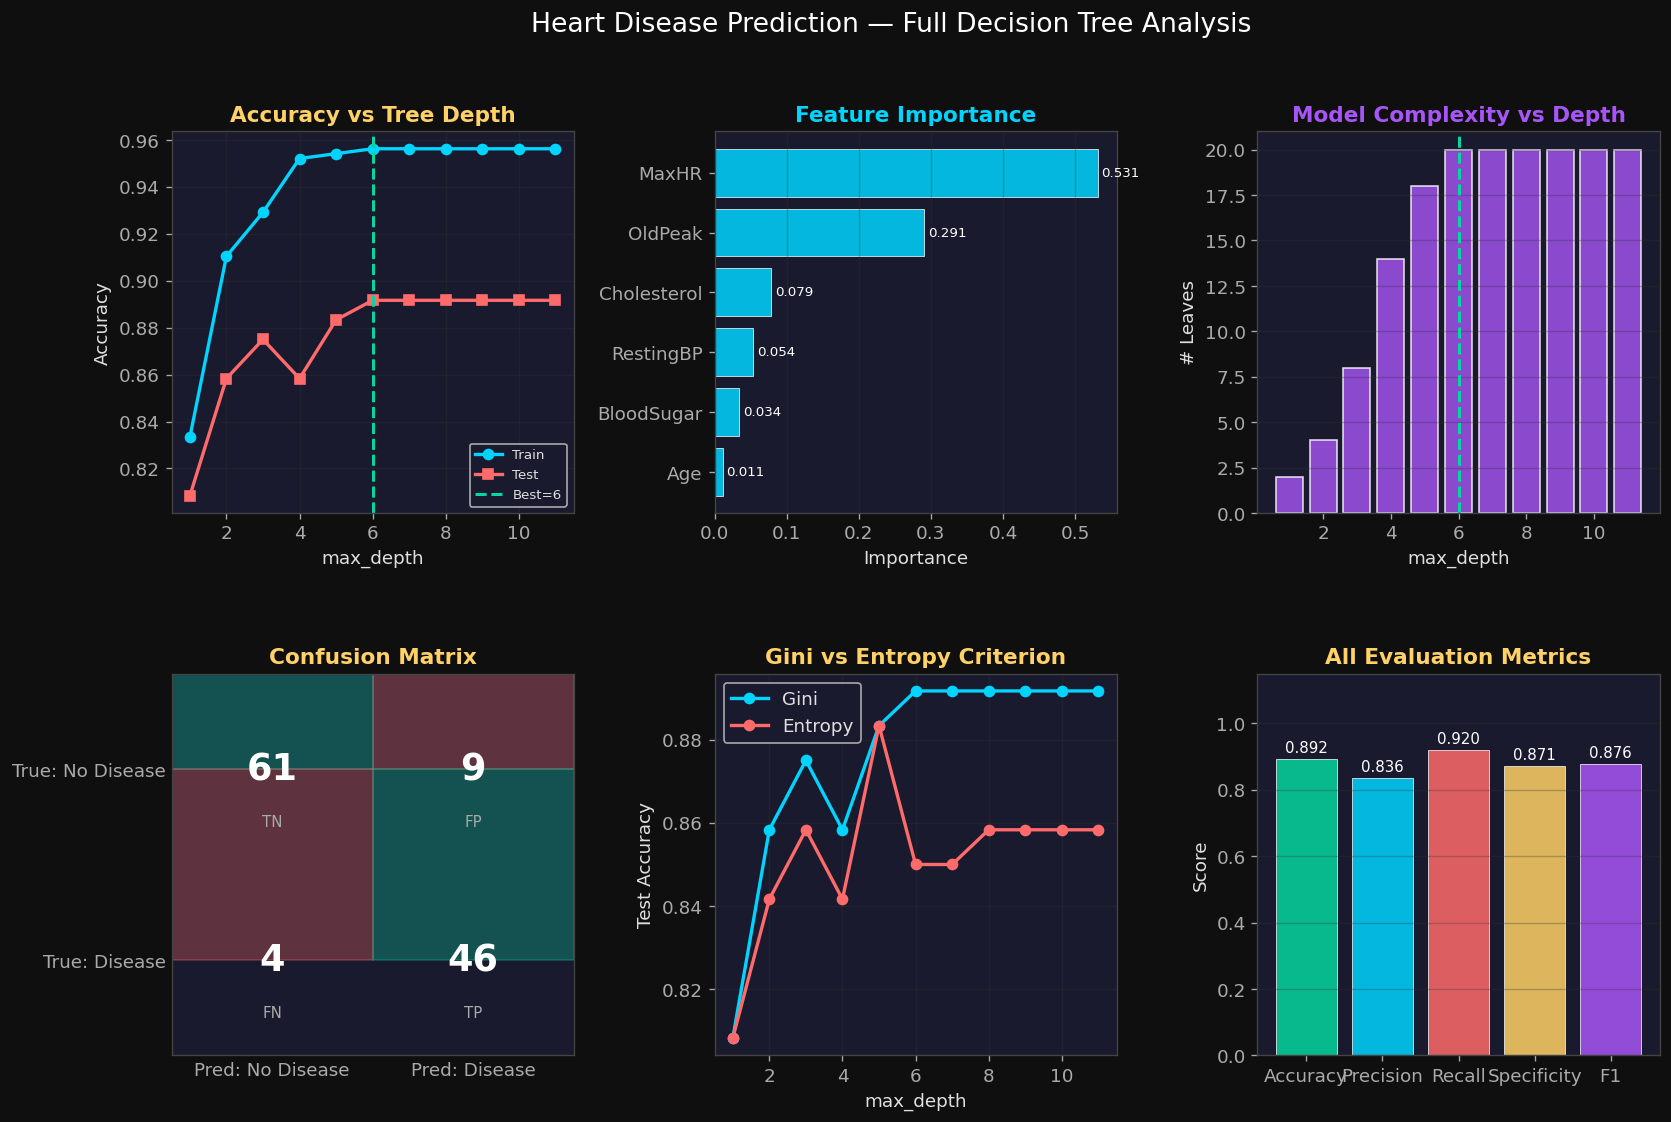

✅ Full analysis dashboard rendered!


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
#  Comprehensive final visualization dashboard
# ─────────────────────────────────────────────────────────────────────────────

depths_h  = list(range(1, 12))
tr_accs_h, te_accs_h, leaves_h = [], [], []
for d in depths_h:
    t = DecisionTreeClassifier(criterion='gini', max_depth=d, min_samples_leaf=5)
    t.fit(X_h_tr, y_h_tr)
    tr_accs_h.append(t.score(X_h_tr, y_h_tr))
    te_accs_h.append(t.score(X_h_te, y_h_te))
    leaves_h.append(t.get_n_leaves())

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Heart Disease Prediction — Full Decision Tree Analysis', fontsize=16, color='white', y=0.98)
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

# 1. Accuracy vs depth
ax1.plot(depths_h, tr_accs_h, 'o-', color=COLORS[0], lw=2, ms=6, label='Train')
ax1.plot(depths_h, te_accs_h, 's-', color=COLORS[1], lw=2, ms=6, label='Test')
ax1.axvline(best_depth_h, color=COLORS[3], ls='--', lw=1.8, label=f'Best={best_depth_h}')
ax1.set_xlabel('max_depth'); ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy vs Tree Depth', color=COLORS[2])
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# 2. Feature importance
imp_h   = heart_tree.feature_importances_
sidx_h  = np.argsort(imp_h)
ax2.barh([heart_features[i] for i in sidx_h], imp_h[sidx_h],
          color=COLORS[0], alpha=0.85, edgecolor='white', lw=0.5)
ax2.set_xlabel('Importance'); ax2.set_title('Feature Importance', color=COLORS[0])
ax2.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(imp_h[sidx_h]):
    ax2.text(v+0.005, i, f'{v:.3f}', va='center', fontsize=8, color='white')

# 3. Number of leaves vs depth
ax3.bar(depths_h, leaves_h, color=COLORS[4], alpha=0.8, edgecolor='white')
ax3.axvline(best_depth_h, color=COLORS[3], ls='--', lw=1.8)
ax3.set_xlabel('max_depth'); ax3.set_ylabel('# Leaves')
ax3.set_title('Model Complexity vs Depth', color=COLORS[4])
ax3.grid(True, alpha=0.3, axis='y')

# 4. Confusion matrix
for i in range(2):
    for j in range(2):
        c = COLORS[3] if i==j else COLORS[1]
        ax4.add_patch(plt.Rectangle((j-0.5, 1.5-i-0.5), 1, 1, color=c, alpha=0.3))
        ax4.text(j, 1-i, str(cm_h[i,j]), ha='center', va='center',
                  fontsize=22, fontweight='bold', color='white')
        lm = {(0,0):'TN',(0,1):'FP',(1,0):'FN',(1,1):'TP'}
        ax4.text(j, 1-i-0.3, lm[(i,j)], ha='center', fontsize=9, color='#aaa')
ax4.set_xlim(-0.5,1.5); ax4.set_ylim(-0.5,1.5)
ax4.set_xticks([0,1]); ax4.set_xticklabels(['Pred: No Disease','Pred: Disease'])
ax4.set_yticks([0,1]); ax4.set_yticklabels(['True: Disease','True: No Disease'])
ax4.set_title('Confusion Matrix', color=COLORS[2]); ax4.tick_params(length=0)

# 5. Criteria comparison: Gini vs Entropy
depths_cmp = list(range(1, 12))
for crit, col in [('gini', COLORS[0]), ('entropy', COLORS[1])]:
    te_a = []
    for d in depths_cmp:
        t = DecisionTreeClassifier(criterion=crit, max_depth=d, min_samples_leaf=5)
        t.fit(X_h_tr, y_h_tr)
        te_a.append(t.score(X_h_te, y_h_te))
    ax5.plot(depths_cmp, te_a, 'o-', color=col, lw=2, ms=6, label=crit.capitalize())
ax5.set_xlabel('max_depth'); ax5.set_ylabel('Test Accuracy')
ax5.set_title('Gini vs Entropy Criterion', color=COLORS[2])
ax5.legend(); ax5.grid(True, alpha=0.3)

# 6. Per-class metrics bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1']
values  = [heart_tree.score(X_h_te, y_h_te), prec, rec, spec, f1]
bar_colors = [COLORS[3], COLORS[0], COLORS[1], COLORS[2], COLORS[4]]
bars = ax6.bar(metrics, values, color=bar_colors, alpha=0.85, edgecolor='white', lw=0.5)
ax6.set_ylim(0, 1.15); ax6.set_ylabel('Score')
ax6.set_title('All Evaluation Metrics', color=COLORS[2])
ax6.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, values):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f'{val:.3f}', ha='center', fontsize=9, color='white')

plt.savefig('decision_tree_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print("✅ Full analysis dashboard rendered!")

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
#  Predict for a new patient — interpretable output
# ─────────────────────────────────────────────────────────────────────────────

def predict_patient(model, features, feature_names):
    """Make a prediction and trace the decision path."""
    x = np.array(features).reshape(1, -1)
    
    # Trace decision path
    node = model.root
    path = []
    while not node.is_leaf:
        fname = feature_names[node.feature_idx]
        val   = features[node.feature_idx]
        goes_left = val <= node.threshold
        decision  = f"{fname} = {val:.1f} {'≤' if goes_left else '>'} {node.threshold:.2f}"
        direction = "→ YES (left)" if goes_left else "→ NO (right)"
        path.append(f"  {decision}  {direction}")
        node = node.left if goes_left else node.right
    
    pred  = model.predict(x)[0]
    label = "⚠️  HIGH RISK (Disease)" if pred == 1 else "✅  LOW RISK (No Disease)"
    
    print("─" * 55)
    print("DECISION PATH:")
    for step in path:
        print(step)
    print(f"\nLeaf: n_samples={node.n_samples}")
    print(f"Prediction: {label}")
    print("─" * 55)
    return pred


print("Patient 1 (young, healthy):")
predict_patient(heart_tree,
    features=[45, 200, 165, 120, 0.5, 0.1],
    feature_names=heart_features)

print("\nPatient 2 (older, risk factors):")
predict_patient(heart_tree,
    features=[62, 280, 120, 148, 3.2, 0.7],
    feature_names=heart_features)

Patient 1 (young, healthy):
───────────────────────────────────────────────────────
DECISION PATH:
  MaxHR = 165.0 > 148.18  → NO (right)
  OldPeak = 0.5 ≤ 2.47  → YES (left)
  BloodSugar = 0.1 ≤ 0.66  → YES (left)
  RestingBP = 120.0 ≤ 149.92  → YES (left)

Leaf: n_samples=183
Prediction: ✅  LOW RISK (No Disease)
───────────────────────────────────────────────────────

Patient 2 (older, risk factors):
───────────────────────────────────────────────────────
DECISION PATH:
  MaxHR = 120.0 ≤ 148.18  → YES (left)
  OldPeak = 3.2 > 0.94  → NO (right)
  BloodSugar = 0.7 > 0.08  → NO (right)
  Cholesterol = 280.0 > 197.72  → NO (right)
  OldPeak = 3.2 > 1.31  → NO (right)

Leaf: n_samples=140
Prediction: ⚠️  HIGH RISK (Disease)
───────────────────────────────────────────────────────


np.float64(1.0)

---
## 📝 Summary & Key Formulas Cheatsheet

### Impurity Measures

| Measure | Formula | Notes |
|---------|---------|-------|
| **Entropy** | $H = -\sum_k p_k \log_2 p_k$ | Range [0, log₂K] |
| **Gini** | $G = 1 - \sum_k p_k^2$ | Range [0, 1-1/K], faster |
| **Variance** | $\sigma^2 = \frac{1}{n}\sum(y_i - \bar{y})^2$ | For regression |

### CART Splitting

$$\text{IG}(S, j, t) = \text{Impurity}(S) - \frac{n_L}{n}\text{Impurity}(S_L) - \frac{n_R}{n}\text{Impurity}(S_R)$$

$$\text{Best split} = \arg\max_{j, t} \text{IG}(S, j, t)$$

### Leaf Predictions

| Task | Leaf Prediction |
|------|-----------------|
| Classification | $\hat{y} = \arg\max_k \text{count}(y=k)$ |
| Regression | $\hat{y} = \frac{1}{n}\sum_{i \in \text{leaf}} y_i$ |

### Feature Importance

$$\text{Importance}(j) = \frac{\sum_{t: \text{split on }j} \frac{n_t}{n} \cdot \text{IG}(t)}{\sum_{\text{all splits}} \frac{n_t}{n} \cdot \text{IG}(t)}$$

### When to Use Decision Trees

| ✅ Use when... | ⚠️ Avoid when... |
|---------------|------------------|
| Interpretability is crucial | Data is small + noisy |
| Mixed feature types | You need smooth probability estimates |
| Non-linear boundaries needed | Tiny class imbalances |
| Feature importance needed | Best accuracy needed (→ use Random Forest) |

---
> **Next Steps:** Decision Trees are the building block of **Random Forests** (many trees, bagging + feature randomness) and **Gradient Boosted Trees** (many trees, each correcting the previous one's errors) — the most powerful classical ML algorithms!